# 04 — Anomaly Detection and Semi-Supervised Learning

## Objective

This notebook applies the complete anomaly detection and semi-supervised learning pipeline to the processed MetroPT-3 industrial air-compressor dataset.

MetroPT-3 is appropriate because its sensor measurements represent a real predictive-maintenance problem and its available event information provides weak or partial labels rather than perfect ground truth.

## Experimental Scope

### Anomaly Detection

The following seven methods are implemented and compared:

1. Isolation Forest
2. One-Class SVM
3. Local Outlier Factor
4. Elliptic Envelope
5. Autoencoder Reconstruction Error
6. DBSCAN-Based Noise Detection
7. Histogram-Based Outlier Score

Controlled synthetic anomalies will be injected using a documented and reproducible strategy. Every method will undergo systematic parameter testing and sensitivity analysis.

Evaluation will include:

- Precision@k
- ROC-AUC
- PR-AUC
- bootstrap confidence intervals
- anomaly-score distributions
- runtime and detected-anomaly proportions

### Semi-Supervised Learning

The following labeled fractions will be tested:

- 5%
- 10%
- 25%

The experiments will include:

- confidence-threshold self-training,
- Label Propagation,
- Label Spreading,
- co-training using justified sensor feature views,
- a fully supervised upper-bound baseline,
- a fully unsupervised lower-bound baseline.

Evaluation will include Accuracy, F1 Score, bootstrap confidence intervals, and learning curves.

In [1]:
# Core libraries
from pathlib import Path
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Statistical and assignment utilities
from scipy.optimize import linear_sum_assignment

# Preprocessing and splitting
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    QuantileTransformer
)
from sklearn.model_selection import (
    train_test_split,
    StratifiedShuffleSplit
)

# Anomaly detection
from sklearn.ensemble import (
    IsolationForest,
    RandomForestClassifier
)
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neural_network import MLPRegressor

# Semi-supervised learning
from sklearn.semi_supervised import (
    SelfTrainingClassifier,
    LabelPropagation,
    LabelSpreading
)
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")
print("Random seed:", RANDOM_STATE)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Scikit-learn version:", sklearn.__version__)

Libraries imported successfully.
Random seed: 42
NumPy version: 2.3.4
Pandas version: 3.0.3
Scikit-learn version: 1.9.0


### 4.1 Data Loading and Verification

The processed MetroPT-3 ten-minute window dataset created in Notebook 2 is loaded without rerunning preprocessing. Aggregating the original sensor readings into non-overlapping ten-minute windows reduces temporal redundancy while preserving operating behaviour and event-related patterns.

The scaling benchmark is also loaded so that the feature transformation used in this notebook remains supported by the earlier quantitative preprocessing comparison.

In [3]:
# Locate the project root.
current_path = Path.cwd()
project_root = None

for candidate_path in [current_path, *current_path.parents]:
    if (
        candidate_path / "datasets" / "processed"
    ).exists():
        project_root = candidate_path
        break

if project_root is None:
    raise FileNotFoundError(
        "The project root containing datasets/processed was not found."
    )

processed_directory = project_root / "datasets" / "processed"
results_directory = project_root / "results"

# Exact filenames created in Notebook 2.
metro_path = (
    processed_directory
    / "metropt3_10min_processed.csv"
)

scaling_results_path = (
    processed_directory
    / "scaling_comparison_results.csv"
)

print("Project root:", project_root)
print("MetroPT-3 file found:", metro_path.exists())
print(
    "Scaling comparison file found:",
    scaling_results_path.exists()
)

if not metro_path.exists():
    raise FileNotFoundError(
        f"Required file was not found: {metro_path}"
    )

if not scaling_results_path.exists():
    raise FileNotFoundError(
        f"Required file was not found: {scaling_results_path}"
    )

metro_df = pd.read_csv(metro_path)
scaling_results_df = pd.read_csv(scaling_results_path)

print("\nMetroPT-3 shape:", metro_df.shape)
print("\nColumns:")
print(metro_df.columns.tolist())

display(metro_df.head())

Project root: C:\Users\dell\Desktop\Aksa_Internship_Tasks\Task-6-Advanced-Unsupervised-Semi-Supervised-and-Anomaly-Detection
MetroPT-3 file found: True
Scaling comparison file found: True

MetroPT-3 shape: (25521, 38)

Columns:
['timestamp', 'Window_Observation_Count', 'TP2_mean', 'TP2_std', 'TP2_min', 'TP2_max', 'TP3_mean', 'TP3_std', 'TP3_min', 'TP3_max', 'H1_mean', 'H1_std', 'H1_min', 'H1_max', 'DV_pressure_mean', 'DV_pressure_std', 'DV_pressure_min', 'DV_pressure_max', 'Reservoirs_mean', 'Reservoirs_std', 'Reservoirs_min', 'Reservoirs_max', 'Oil_temperature_mean', 'Oil_temperature_std', 'Oil_temperature_min', 'Oil_temperature_max', 'Motor_current_mean', 'Motor_current_std', 'Motor_current_min', 'Motor_current_max', 'COMP_active_ratio', 'DV_eletric_active_ratio', 'Towers_active_ratio', 'MPG_active_ratio', 'LPS_active_ratio', 'Pressure_switch_active_ratio', 'Oil_level_active_ratio', 'Caudal_impulses_active_ratio']


,timestamp,Window_Observation_Count,TP2_mean,TP2_std,TP2_min,TP2_max,TP3_mean,TP3_std,TP3_min,TP3_max,...,Motor_current_min,Motor_current_max,COMP_active_ratio,DV_eletric_active_ratio,Towers_active_ratio,MPG_active_ratio,LPS_active_ratio,Pressure_switch_active_ratio,Oil_level_active_ratio,Caudal_impulses_active_ratio
0,2020-02-01 00:00:00,61,-0.013016,0.001008,-0.014,-0.012,9.053705,0.177553,8.760,9.358,...,0.0375,0.0425,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0
1,2020-02-01 00:10:00,61,-0.013836,0.000757,-0.016,-0.012,8.480361,0.156157,8.222,8.750,...,0.0350,0.0400,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0
2,2020-02-01 00:20:00,60,1.570033,3.580866,-0.026,10.314,9.169833,0.793773,8.068,10.098,...,0.0400,6.2825,0.816667,0.183333,0.916667,0.816667,0.0,1.0,1.0,1.0
3,2020-02-01 00:30:00,61,-0.012820,0.001118,-0.014,-0.010,9.300000,0.182287,8.994,9.608,...,0.0375,3.9100,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0
4,2020-02-01 00:40:00,60,-0.013833,0.000763,-0.016,-0.012,8.703833,0.162246,8.436,8.984,...,0.0375,0.0425,1.000000,0.000000,1.000000,1.000000,0.0,1.0,1.0,1.0


####  4.1.1 Dataset Structure and Integrity

Before constructing weak labels or synthetic anomalies, the processed dataset is checked for timestamp coverage, missing values, duplicate windows, infinite values, constant features, and incomplete aggregation windows.

The timestamp is retained for temporal analysis but is not used directly as a numerical model feature. `Window_Observation_Count` is treated as a data-quality indicator rather than an equipment-condition feature.

In [4]:
# Parse and validate the timestamp column.
metro_df["timestamp"] = pd.to_datetime(
    metro_df["timestamp"],
    errors="coerce"
)

numeric_columns = metro_df.select_dtypes(
    include=np.number
).columns.tolist()

sensor_feature_columns = [
    column for column in numeric_columns
    if column != "Window_Observation_Count"
]

missing_values = int(metro_df.isna().sum().sum())

numeric_values = metro_df[
    numeric_columns
].to_numpy(dtype=float)

infinite_values = int(
    np.isinf(numeric_values).sum()
)

duplicate_rows = int(metro_df.duplicated().sum())
duplicate_timestamps = int(
    metro_df["timestamp"].duplicated().sum()
)

constant_features = [
    column for column in sensor_feature_columns
    if metro_df[column].nunique(dropna=False) <= 1
]

print(
    "Time range:",
    metro_df["timestamp"].min(),
    "to",
    metro_df["timestamp"].max()
)
print("Timestamp parsing failures:", metro_df["timestamp"].isna().sum())
print("Duplicate rows:", duplicate_rows)
print("Duplicate timestamps:", duplicate_timestamps)
print("Total missing values:", missing_values)
print("Total infinite values:", infinite_values)
print("Candidate sensor features:", len(sensor_feature_columns))
print("Constant sensor features:", constant_features)

print("\nWindow observation-count summary:")
display(
    metro_df["Window_Observation_Count"]
    .describe()
    .to_frame("Value")
)

print("\nScaling comparison columns:")
print(scaling_results_df.columns.tolist())

display(scaling_results_df)

Time range: 2020-02-01 00:00:00 to 2020-09-01 03:50:00
Timestamp parsing failures: 0
Duplicate rows: 0
Duplicate timestamps: 0
Total missing values: 0
Total infinite values: 0
Candidate sensor features: 36
Constant sensor features: []

Window observation-count summary:


,Value
count,25521.000000
mean,59.439207
std,5.393664
min,1.000000
25%,60.000000
50%,60.000000
75%,61.000000
max,61.000000



Scaling comparison columns:
['Dataset', 'Scaler', 'K', 'Silhouette', 'Davies_Bouldin', 'Calinski_Harabasz']


,Dataset,Scaler,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,Room Occupancy,StandardScaler,2,0.626004,1.044245,6754.792958
1,Room Occupancy,StandardScaler,3,0.452737,1.375118,4834.296022
2,Room Occupancy,StandardScaler,4,0.442479,1.576606,4145.213567
3,Room Occupancy,StandardScaler,5,0.438244,1.807206,3509.731777
4,Room Occupancy,StandardScaler,6,0.289158,1.654647,3177.431920
5,Room Occupancy,MinMaxScaler,2,0.623972,0.954565,8706.256593
6,Room Occupancy,MinMaxScaler,3,0.485004,1.261377,6718.148817
7,Room Occupancy,MinMaxScaler,4,0.482257,1.482708,5695.515363
8,Room Occupancy,MinMaxScaler,5,0.403195,1.487661,4629.877449
9,Room Occupancy,MinMaxScaler,6,0.348706,1.330363,4780.978817


**Observation:** The processed MetroPT-3 dataset contains 25,521 unique ten-minute windows covering February to September 2020. All 36 candidate sensor features are complete, finite, and non-constant. RobustScaler produced the strongest clustering performance in the earlier scaling comparison, reaching a maximum Silhouette Score of 0.9026. It is therefore selected for the anomaly and semi-supervised pipelines. Window observation counts range from 1 to 61, so incomplete windows require further examination before modelling.

#### 4.1.2 Window Completeness and Scaling Selection

A normal ten-minute window contains approximately 60 observations. Windows with substantially fewer observations may represent gaps in data collection rather than genuine equipment behaviour. Several completeness thresholds are compared before selecting a defensible filtering rule.

In [5]:
# Summarize MetroPT-3 scaling performance.
metro_scaling_results = scaling_results_df[
    scaling_results_df["Dataset"] == "MetroPT-3"
].copy()

best_scaling_by_method = (
    metro_scaling_results
    .sort_values("Silhouette", ascending=False)
    .groupby("Scaler", as_index=False)
    .first()
    .sort_values("Silhouette", ascending=False)
    .reset_index(drop=True)
)

print("Best MetroPT-3 result for each scaler:")
display(
    best_scaling_by_method.style.format({
        "Silhouette": "{:.4f}",
        "Davies_Bouldin": "{:.4f}",
        "Calinski_Harabasz": "{:.4f}"
    })
)

# Compare possible observation-completeness thresholds.
completeness_thresholds = [30, 40, 50, 55, 60]

completeness_results = []

for threshold in completeness_thresholds:
    retained_rows = int(
        (
            metro_df["Window_Observation_Count"]
            >= threshold
        ).sum()
    )

    completeness_results.append({
        "Minimum_Observations": threshold,
        "Retained_Windows": retained_rows,
        "Removed_Windows": len(metro_df) - retained_rows,
        "Retained_Percentage": (
            retained_rows / len(metro_df) * 100
        )
    })

completeness_df = pd.DataFrame(completeness_results)

print("\nCompleteness-threshold comparison:")
display(
    completeness_df.style.format({
        "Retained_Percentage": "{:.2f}%"
    })
)

print("\nMost common observation counts:")
display(
    metro_df["Window_Observation_Count"]
    .value_counts()
    .sort_index(ascending=False)
    .head(15)
    .rename_axis("Observation_Count")
    .to_frame("Number_of_Windows")
)

Best MetroPT-3 result for each scaler:


,Scaler,Dataset,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,RobustScaler,MetroPT-3,6,0.9026,0.4736,82213.4511
1,MinMaxScaler,MetroPT-3,3,0.6138,0.5780,35914.2088
2,QuantileTransformer,MetroPT-3,6,0.5041,0.8299,13706.2145
3,StandardScaler,MetroPT-3,3,0.3906,0.9897,13818.7408



Completeness-threshold comparison:


,Minimum_Observations,Retained_Windows,Removed_Windows,Retained_Percentage
0,30,25256,265,98.96%
1,40,25149,372,98.54%
2,50,24752,769,96.99%
3,55,23986,1535,93.99%
4,60,23925,1596,93.75%



Most common observation counts:


,Number_of_Windows
Observation_Count,
61,12644
60,11281
59,26
58,7
57,8
56,8
55,12
54,8
53,6


**Observation:** RobustScaler clearly outperformed the other transformations and is retained for modelling. A minimum completeness threshold of 50 observations preserves 24,752 windows (96.99%) while removing 769 severely incomplete windows. Raising the threshold to 55 would remove twice as many windows for a relatively small improvement in completeness. Therefore, 50 observations provides a practical balance between data quality and sample retention.

### 4.2 Weak Ground-Truth Construction

MetroPT-3 does not contain a direct label for every sensor observation. Instead, the dataset documentation provides failure intervals obtained from company maintenance reports. These intervals are converted into weak binary labels:

- `0`: no reported failure during the window,
- `1`: the window falls inside a reported failure interval.

The labels are considered weak because maintenance reports may omit minor or undiagnosed faults, while windows inside a reported interval may not all display equally abnormal sensor behaviour.

The four documented high-stress air-leak periods are:

| Failure | Start | End |
|---|---|---|
| F1 | 2020-04-18 00:00 | 2020-04-18 23:59 |
| F2 | 2020-05-29 23:30 | 2020-05-30 06:00 |
| F3 | 2020-06-05 10:00 | 2020-06-07 14:30 |
| F4 | 2020-07-15 14:30 | 2020-07-15 19:00 |

Source: [UCI MetroPT-3 Dataset](https://archive.ics.uci.edu/dataset/791/metropt%2B3%2Bdataset)

In [6]:
# Remove severely incomplete aggregation windows.
MINIMUM_WINDOW_OBSERVATIONS = 50

metro_model_df = (
    metro_df[
        metro_df["Window_Observation_Count"]
        >= MINIMUM_WINDOW_OBSERVATIONS
    ]
    .copy()
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Official failure intervals reported with the MetroPT-3 dataset.
failure_intervals_df = pd.DataFrame([
    {
        "Failure_ID": "F1",
        "Start": "2020-04-18 00:00:00",
        "End": "2020-04-18 23:59:00",
        "Failure_Type": "Air leak"
    },
    {
        "Failure_ID": "F2",
        "Start": "2020-05-29 23:30:00",
        "End": "2020-05-30 06:00:00",
        "Failure_Type": "Air leak"
    },
    {
        "Failure_ID": "F3",
        "Start": "2020-06-05 10:00:00",
        "End": "2020-06-07 14:30:00",
        "Failure_Type": "Air leak"
    },
    {
        "Failure_ID": "F4",
        "Start": "2020-07-15 14:30:00",
        "End": "2020-07-15 19:00:00",
        "Failure_Type": "Air leak"
    }
])

failure_intervals_df["Start"] = pd.to_datetime(
    failure_intervals_df["Start"]
)
failure_intervals_df["End"] = pd.to_datetime(
    failure_intervals_df["End"]
)

# Create weak labels from the documented intervals.
metro_model_df["Weak_Failure_Label"] = 0
metro_model_df["Failure_ID"] = "No reported failure"

for _, failure in failure_intervals_df.iterrows():
    interval_mask = metro_model_df["timestamp"].between(
        failure["Start"],
        failure["End"],
        inclusive="both"
    )

    metro_model_df.loc[
        interval_mask,
        "Weak_Failure_Label"
    ] = 1

    metro_model_df.loc[
        interval_mask,
        "Failure_ID"
    ] = failure["Failure_ID"]

# Summarize the created weak labels.
failure_window_summary = (
    metro_model_df[
        metro_model_df["Weak_Failure_Label"] == 1
    ]
    .groupby("Failure_ID")
    .size()
    .reindex(failure_intervals_df["Failure_ID"])
    .fillna(0)
    .astype(int)
    .reset_index(name="Labelled_Windows")
)

weak_label_distribution = (
    metro_model_df["Weak_Failure_Label"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "No reported failure",
        1: "Reported failure"
    })
    .to_frame("Windows")
)

weak_label_distribution["Percentage"] = (
    weak_label_distribution["Windows"]
    / len(metro_model_df)
    * 100
)

print("Original windows:", len(metro_df))
print("Retained complete windows:", len(metro_model_df))
print("Removed incomplete windows:", len(metro_df) - len(metro_model_df))
print("Sensor features retained:", len(sensor_feature_columns))

print("\nWeak-label distribution:")
display(
    weak_label_distribution.style.format({
        "Percentage": "{:.2f}%"
    })
)

print("\nReported failure windows:")
display(failure_window_summary)

Original windows: 25521
Retained complete windows: 24752
Removed incomplete windows: 769
Sensor features retained: 36

Weak-label distribution:


,Windows,Percentage
Weak_Failure_Label,,
No reported failure,24259,98.01%
Reported failure,493,1.99%



Reported failure windows:


,Failure_ID,Labelled_Windows
0,F1,142
1,F2,40
2,F3,284
3,F4,27


**Observation:** After completeness filtering, 493 of 24,752 windows (1.99%) fall within documented failure intervals. The strong imbalance reflects a realistic predictive-maintenance setting where failures are rare. F3 contributes the majority of labelled failure windows, while F2 and F4 are brief. These labels remain weak because windows outside the four reports cannot be guaranteed to represent completely normal operation.

### 4.3 Anomaly Detection Benchmark

The anomaly detectors are first evaluated using a controlled synthetic benchmark. Windows outside the reported failure intervals provide a weak-normal reference population.

Training and evaluation data are separated chronologically. The scaler is fitted only on the training portion to prevent information leakage. A controlled sample is used because One-Class SVM, LOF, covariance estimation, and pairwise-distance methods become computationally expensive on the complete dataset.

Most detectors are trained as novelty detectors using only weak-normal reference data. DBSCAN is treated separately as an outlier detector because it identifies noise while fitting the evaluation dataset.

#### 4.3.1 Normal Reference and Evaluation Split

The earliest 70% of weak-normal windows form the training pool, while the remaining 30% form the temporally later evaluation pool. Reproducible samples of 6,000 training windows and 4,000 evaluation windows are used.

The timestamp, aggregation count, and weak-label columns are excluded from the model features. RobustScaler is fitted only on the selected normal training windows.

In [7]:
# Construct a weak-normal reference population.
weak_normal_df = (
    metro_model_df[
        metro_model_df["Weak_Failure_Label"] == 0
    ]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

NORMAL_TRAIN_FRACTION = 0.70
ANOMALY_TRAIN_SIZE = 6000
ANOMALY_EVALUATION_NORMAL_SIZE = 4000

normal_split_position = int(
    len(weak_normal_df) * NORMAL_TRAIN_FRACTION
)

normal_training_pool = weak_normal_df.iloc[
    :normal_split_position
].copy()

normal_evaluation_pool = weak_normal_df.iloc[
    normal_split_position:
].copy()

rng = np.random.default_rng(RANDOM_STATE)

training_sample_indices = rng.choice(
    len(normal_training_pool),
    size=min(
        ANOMALY_TRAIN_SIZE,
        len(normal_training_pool)
    ),
    replace=False
)

evaluation_sample_indices = rng.choice(
    len(normal_evaluation_pool),
    size=min(
        ANOMALY_EVALUATION_NORMAL_SIZE,
        len(normal_evaluation_pool)
    ),
    replace=False
)

normal_training_sample = (
    normal_training_pool
    .iloc[training_sample_indices]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

normal_evaluation_sample = (
    normal_evaluation_pool
    .iloc[evaluation_sample_indices]
    .sort_values("timestamp")
    .reset_index(drop=True)
)

X_anomaly_train_raw = normal_training_sample[
    sensor_feature_columns
].copy()

X_anomaly_evaluation_normal_raw = (
    normal_evaluation_sample[
        sensor_feature_columns
    ].copy()
)

# Fit scaling only on the normal training reference.
anomaly_scaler = RobustScaler()

X_anomaly_train = anomaly_scaler.fit_transform(
    X_anomaly_train_raw
)

X_anomaly_evaluation_normal = anomaly_scaler.transform(
    X_anomaly_evaluation_normal_raw
)

print("Weak-normal windows available:", len(weak_normal_df))
print("Training-pool windows:", len(normal_training_pool))
print("Evaluation-pool windows:", len(normal_evaluation_pool))

print("\nSelected normal training shape:", X_anomaly_train.shape)
print(
    "Selected normal evaluation shape:",
    X_anomaly_evaluation_normal.shape
)

print(
    "\nTraining period:",
    normal_training_sample["timestamp"].min(),
    "to",
    normal_training_sample["timestamp"].max()
)

print(
    "Evaluation period:",
    normal_evaluation_sample["timestamp"].min(),
    "to",
    normal_evaluation_sample["timestamp"].max()
)

print(
    "Temporal overlap:",
    normal_training_sample["timestamp"].max()
    >= normal_evaluation_sample["timestamp"].min()
)

Weak-normal windows available: 24259
Training-pool windows: 16981
Evaluation-pool windows: 7278

Selected normal training shape: (6000, 36)
Selected normal evaluation shape: (4000, 36)

Training period: 2020-02-01 00:00:00 to 2020-06-30 16:30:00
Evaluation period: 2020-06-30 17:00:00 to 2020-09-01 03:20:00
Temporal overlap: False


**Observation:** The normal-reference data were separated chronologically with no temporal overlap. Six thousand earlier windows are used for detector training, while 4,000 later normal windows form the base evaluation set. RobustScaler was fitted only on the training period, preventing future information from influencing model preparation.

#### 4.3.2 Synthetic Anomaly Injection Strategy

Synthetic anomalies are added only to the evaluation set; the detector-training data remain unchanged and weak-normal.

Two complementary anomaly mechanisms are used:

1. **Sparse feature perturbation:** Six continuous sensor statistics are shifted by four to seven training-set interquartile ranges. One digital activity-ratio feature is also moved toward its opposite operating state. This represents a point anomaly affecting a limited sensor subset.

2. **Multivariate distribution shift:** Fourteen continuous features are shifted together by 2.5 to four interquartile ranges, while two activity-ratio features are reversed. This represents a broader abnormal operating state involving several sensor subsystems.

For a selected continuous feature \(j\), injection follows:

$$
x'_j=x_j+s\lambda IQR_j
$$

where \(s\in\{-1,+1\}\) controls direction and \(\lambda\) controls perturbation strength. When a feature has zero IQR, its training standard deviation is used instead.

Synthetic anomalies form approximately 5% of the final benchmark. This preserves realistic imbalance while providing enough known anomalies for metric estimation. The original reported failure windows are not used in this synthetic benchmark and will be evaluated separately.

In [8]:
# Create a reproducible imbalanced synthetic-anomaly benchmark.
SYNTHETIC_ANOMALY_FRACTION = 0.05

injection_rng = np.random.default_rng(
    RANDOM_STATE + 1
)

continuous_feature_columns = [
    column for column in sensor_feature_columns
    if not column.endswith("_active_ratio")
]

ratio_feature_columns = [
    column for column in sensor_feature_columns
    if column.endswith("_active_ratio")
]

normal_evaluation_count = len(
    X_anomaly_evaluation_normal_raw
)

synthetic_anomaly_count = int(round(
    normal_evaluation_count
    * SYNTHETIC_ANOMALY_FRACTION
    / (1 - SYNTHETIC_ANOMALY_FRACTION)
))

base_indices = injection_rng.choice(
    normal_evaluation_count,
    size=synthetic_anomaly_count,
    replace=False
)

X_synthetic_raw = (
    X_anomaly_evaluation_normal_raw
    .iloc[base_indices]
    .reset_index(drop=True)
    .copy()
)

# Calculate training-based perturbation scales.
training_q1 = X_anomaly_train_raw.quantile(0.25)
training_q3 = X_anomaly_train_raw.quantile(0.75)
training_iqr = training_q3 - training_q1
training_std = X_anomaly_train_raw.std()

perturbation_scale = training_iqr.copy()

zero_iqr_mask = perturbation_scale <= 1e-12

perturbation_scale.loc[zero_iqr_mask] = (
    training_std.loc[zero_iqr_mask]
)

perturbation_scale = perturbation_scale.replace(
    0,
    1.0
)

injection_types = []

for row_index in range(synthetic_anomaly_count):
    if row_index < synthetic_anomaly_count // 2:
        injection_type = "Sparse perturbation"

        selected_continuous = injection_rng.choice(
            continuous_feature_columns,
            size=6,
            replace=False
        )

        selected_ratios = injection_rng.choice(
            ratio_feature_columns,
            size=1,
            replace=False
        )

        shift_strength = injection_rng.uniform(
            4.0,
            7.0,
            size=len(selected_continuous)
        )

    else:
        injection_type = "Multivariate shift"

        selected_continuous = injection_rng.choice(
            continuous_feature_columns,
            size=14,
            replace=False
        )

        selected_ratios = injection_rng.choice(
            ratio_feature_columns,
            size=2,
            replace=False
        )

        shift_strength = injection_rng.uniform(
            2.5,
            4.0,
            size=len(selected_continuous)
        )

    shift_directions = injection_rng.choice(
        [-1.0, 1.0],
        size=len(selected_continuous)
    )

    original_values = X_synthetic_raw.loc[
        row_index,
        selected_continuous
    ].to_numpy(dtype=float)

    feature_scales = perturbation_scale.loc[
        selected_continuous
    ].to_numpy(dtype=float)

    X_synthetic_raw.loc[
        row_index,
        selected_continuous
    ] = (
        original_values
        + shift_directions
        * shift_strength
        * feature_scales
    )

    # Reverse selected activity-ratio states.
    current_ratios = X_synthetic_raw.loc[
        row_index,
        selected_ratios
    ].to_numpy(dtype=float)

    low_replacements = injection_rng.uniform(
        0.0,
        0.20,
        size=len(selected_ratios)
    )

    high_replacements = injection_rng.uniform(
        0.80,
        1.0,
        size=len(selected_ratios)
    )

    reversed_ratios = np.where(
        current_ratios >= 0.50,
        low_replacements,
        high_replacements
    )

    X_synthetic_raw.loc[
        row_index,
        selected_ratios
    ] = reversed_ratios

    injection_types.append(injection_type)

# Apply the scaler fitted only on normal training data.
X_synthetic_scaled = anomaly_scaler.transform(
    X_synthetic_raw
)

X_anomaly_benchmark = np.vstack([
    X_anomaly_evaluation_normal,
    X_synthetic_scaled
])

y_anomaly_benchmark = np.concatenate([
    np.zeros(
        len(X_anomaly_evaluation_normal),
        dtype=int
    ),
    np.ones(
        len(X_synthetic_scaled),
        dtype=int
    )
])

benchmark_injection_type = np.concatenate([
    np.repeat(
        "Original weak-normal",
        len(X_anomaly_evaluation_normal)
    ),
    np.asarray(injection_types)
])

# Shuffle normal and synthetic observations together.
benchmark_permutation = injection_rng.permutation(
    len(X_anomaly_benchmark)
)

X_anomaly_benchmark = X_anomaly_benchmark[
    benchmark_permutation
]

y_anomaly_benchmark = y_anomaly_benchmark[
    benchmark_permutation
]

benchmark_injection_type = benchmark_injection_type[
    benchmark_permutation
]

benchmark_summary_df = (
    pd.Series(
        benchmark_injection_type,
        name="Observation_Type"
    )
    .value_counts()
    .rename_axis("Observation_Type")
    .reset_index(name="Windows")
)

benchmark_summary_df["Percentage"] = (
    benchmark_summary_df["Windows"]
    / len(X_anomaly_benchmark)
    * 100
)

print("Normal evaluation windows:", normal_evaluation_count)
print("Injected synthetic anomalies:", synthetic_anomaly_count)
print("Final benchmark shape:", X_anomaly_benchmark.shape)
print(
    "Final anomaly prevalence:",
    f"{y_anomaly_benchmark.mean() * 100:.2f}%"
)
print(
    "All benchmark values finite:",
    np.isfinite(X_anomaly_benchmark).all()
)

display(
    benchmark_summary_df.style.format({
        "Percentage": "{:.2f}%"
    })
)

Normal evaluation windows: 4000
Injected synthetic anomalies: 211
Final benchmark shape: (4211, 36)
Final anomaly prevalence: 5.01%
All benchmark values finite: True


,Observation_Type,Windows,Percentage
0,Original weak-normal,4000,94.99%
1,Multivariate shift,106,2.52%
2,Sparse perturbation,105,2.49%


**Observation:** The final controlled benchmark contains 4,211 windows with an anomaly prevalence of 5.01%. Sparse perturbations and multivariate shifts contribute almost equal numbers of anomalies. All transformed values are finite, confirming that the injection and scaling procedures introduced no invalid numerical values.

#### 4.3.3 Synthetic Injection Verification

The injected observations should differ meaningfully from later normal operation without corrupting the original evaluation windows. Their robust-scaled distance and maximum feature deviation are compared before anomaly detectors are fitted.

This verification does not measure detector performance. It only confirms that the synthetic mechanisms produced measurable feature-space changes.

,Observation_Type,Windows,Median_Distance,Mean_Distance,Median_Maximum_Deviation,Mean_Maximum_Deviation
0,Original weak-normal,4000,3.7367,204.8712,1.3253,189.1101
1,Synthetic anomaly,211,14.7915,216.2348,7.0028,193.1516


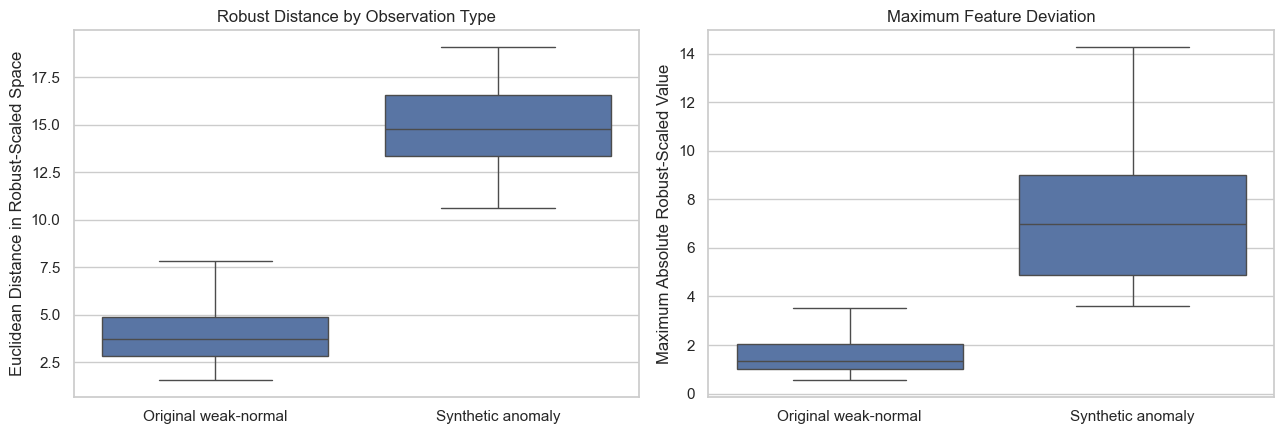

In [9]:
# Compare normal and synthetic observations in robust-scaled space.
normal_distance = np.linalg.norm(
    X_anomaly_evaluation_normal,
    axis=1
)

synthetic_distance = np.linalg.norm(
    X_synthetic_scaled,
    axis=1
)

normal_max_deviation = np.max(
    np.abs(X_anomaly_evaluation_normal),
    axis=1
)

synthetic_max_deviation = np.max(
    np.abs(X_synthetic_scaled),
    axis=1
)

injection_verification_df = pd.DataFrame({
    "Observation_Type": (
        ["Original weak-normal"]
        * len(normal_distance)
        + ["Synthetic anomaly"]
        * len(synthetic_distance)
    ),
    "Robust_Distance": np.concatenate([
        normal_distance,
        synthetic_distance
    ]),
    "Maximum_Absolute_Deviation": np.concatenate([
        normal_max_deviation,
        synthetic_max_deviation
    ])
})

verification_summary_df = (
    injection_verification_df
    .groupby("Observation_Type")
    .agg(
        Windows=("Robust_Distance", "size"),
        Median_Distance=("Robust_Distance", "median"),
        Mean_Distance=("Robust_Distance", "mean"),
        Median_Maximum_Deviation=(
            "Maximum_Absolute_Deviation",
            "median"
        ),
        Mean_Maximum_Deviation=(
            "Maximum_Absolute_Deviation",
            "mean"
        )
    )
    .reset_index()
)

display(
    verification_summary_df.style.format({
        "Median_Distance": "{:.4f}",
        "Mean_Distance": "{:.4f}",
        "Median_Maximum_Deviation": "{:.4f}",
        "Mean_Maximum_Deviation": "{:.4f}"
    })
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(
    data=injection_verification_df,
    x="Observation_Type",
    y="Robust_Distance",
    showfliers=False,
    ax=axes[0]
)

axes[0].set_title("Robust Distance by Observation Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Euclidean Distance in Robust-Scaled Space")

sns.boxplot(
    data=injection_verification_df,
    x="Observation_Type",
    y="Maximum_Absolute_Deviation",
    showfliers=False,
    ax=axes[1]
)

axes[1].set_title("Maximum Feature Deviation")
axes[1].set_xlabel("")
axes[1].set_ylabel("Maximum Absolute Robust-Scaled Value")

plt.tight_layout()
plt.show()

**Observation:** Synthetic anomalies show substantially greater median distance and feature deviation than the original evaluation windows, confirming that the injection mechanisms created measurable abnormal patterns. The means are much larger than the medians because some unreported MetroPT-3 windows already contain extreme sensor values. This demonstrates the limitation of weak maintenance labels: an unreported window is not necessarily perfectly normal.

#### 4.3.4 Anomaly Evaluation Metrics

All anomaly scores are oriented so that a larger value indicates greater abnormality.

**Precision@k** measures the proportion of true anomalies among the \(k\) highest-scoring observations:

$$
Precision@k=
\frac{\text{True anomalies among top }k}{k}
$$

Here, \(k\) equals the known number of injected anomalies.

**ROC-AUC** measures how often a randomly selected anomaly receives a higher score than a randomly selected normal observation.

**PR-AUC** is calculated using Average Precision. It is the primary selection metric because the anomaly prevalence is only about 5%. Under imbalance, ROC-AUC can remain high because of the large number of correctly ranked normal observations, whereas PR-AUC directly reflects the detector's ability to retrieve rare anomalies. A random model's expected PR-AUC is approximately equal to the anomaly prevalence.

Final metrics will include 95% bootstrap confidence intervals obtained by resampling evaluation observations with replacement.

In [10]:
# Define reusable anomaly-evaluation functions.
ANOMALY_K = int(y_anomaly_benchmark.sum())
BOOTSTRAP_ITERATIONS = 500
CONFIDENCE_LEVEL = 0.95


def precision_at_k(
    y_true,
    anomaly_scores,
    k=None
):
    y_true = np.asarray(y_true, dtype=int)
    anomaly_scores = np.asarray(
        anomaly_scores,
        dtype=float
    )

    if k is None:
        k = int(y_true.sum())

    k = max(1, min(int(k), len(y_true)))

    top_indices = np.argpartition(
        anomaly_scores,
        -k
    )[-k:]

    return float(y_true[top_indices].mean())


def calculate_anomaly_metrics(
    y_true,
    anomaly_scores,
    k=None
):
    y_true = np.asarray(y_true, dtype=int)
    anomaly_scores = np.asarray(
        anomaly_scores,
        dtype=float
    )

    return {
        "Precision_at_k": precision_at_k(
            y_true,
            anomaly_scores,
            k=k
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            anomaly_scores
        ),
        "PR_AUC": average_precision_score(
            y_true,
            anomaly_scores
        )
    }


def bootstrap_anomaly_metrics(
    y_true,
    anomaly_scores,
    k=None,
    n_iterations=BOOTSTRAP_ITERATIONS,
    confidence_level=CONFIDENCE_LEVEL,
    random_state=RANDOM_STATE
):
    y_true = np.asarray(y_true, dtype=int)
    anomaly_scores = np.asarray(
        anomaly_scores,
        dtype=float
    )

    if k is None:
        k = int(y_true.sum())

    point_estimates = calculate_anomaly_metrics(
        y_true,
        anomaly_scores,
        k=k
    )

    bootstrap_rng = np.random.default_rng(
        random_state
    )

    bootstrap_values = {
        metric_name: []
        for metric_name in point_estimates
    }

    for _ in range(n_iterations):
        sample_indices = bootstrap_rng.integers(
            0,
            len(y_true),
            size=len(y_true)
        )

        y_sample = y_true[sample_indices]
        score_sample = anomaly_scores[
            sample_indices
        ]

        # ROC-AUC and PR-AUC require both classes.
        if np.unique(y_sample).size < 2:
            continue

        sample_metrics = calculate_anomaly_metrics(
            y_sample,
            score_sample,
            k=k
        )

        for metric_name, metric_value in (
            sample_metrics.items()
        ):
            bootstrap_values[metric_name].append(
                metric_value
            )

    alpha = (1 - confidence_level) / 2
    confidence_rows = []

    for metric_name, estimate in (
        point_estimates.items()
    ):
        metric_distribution = np.asarray(
            bootstrap_values[metric_name]
        )

        confidence_rows.append({
            "Metric": metric_name,
            "Estimate": estimate,
            "CI_Lower": np.quantile(
                metric_distribution,
                alpha
            ),
            "CI_Upper": np.quantile(
                metric_distribution,
                1 - alpha
            ),
            "Bootstrap_Samples": len(
                metric_distribution
            )
        })

    return pd.DataFrame(confidence_rows)


# Sanity-check the metric implementation.
metric_test_rng = np.random.default_rng(
    RANDOM_STATE + 2
)

random_test_scores = metric_test_rng.random(
    len(y_anomaly_benchmark)
)

ideal_test_scores = (
    y_anomaly_benchmark
    + metric_test_rng.normal(
        0,
        0.01,
        size=len(y_anomaly_benchmark)
    )
)

metric_sanity_df = pd.DataFrame([
    {
        "Score_Type": "Random scores",
        **calculate_anomaly_metrics(
            y_anomaly_benchmark,
            random_test_scores,
            k=ANOMALY_K
        )
    },
    {
        "Score_Type": "Ideal scores",
        **calculate_anomaly_metrics(
            y_anomaly_benchmark,
            ideal_test_scores,
            k=ANOMALY_K
        )
    }
])

print("Precision@k uses k =", ANOMALY_K)
print(
    "Random PR-AUC reference:",
    f"{y_anomaly_benchmark.mean():.4f}"
)

display(
    metric_sanity_df.style.format({
        "Precision_at_k": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

Precision@k uses k = 211
Random PR-AUC reference: 0.0501


,Score_Type,Precision_at_k,ROC_AUC,PR_AUC
0,Random scores,0.0616,0.5047,0.0534
1,Ideal scores,1.0000,1.0000,1.0000


**Observation:** The evaluation functions passed their sanity check. Random ranking produced ROC-AUC near 0.5 and PR-AUC near the 5% anomaly prevalence, while ideal ranking achieved perfect scores. This confirms that the score orientation and Precision@k implementation are correct.

### 4.4 Anomaly Detection Methods

Each anomaly detector is tuned using a predefined parameter grid. PR-AUC is the primary selection metric, followed by Precision@k and ROC-AUC. Parameter sensitivity is visualized rather than reporting only the selected configuration.

#### 4.4.1 Isolation Forest

Isolation Forest recursively partitions observations using randomly selected features and split values. An anomaly generally requires fewer partitions to become isolated than a normal observation.

Its anomaly score is based on expected path length:

$$
s(x,n)=2^{-\frac{E[h(x)]}{c(n)}}
$$

where \(E[h(x)]\) is the average isolation path length and \(c(n)\) normalizes the expected path length for a sample of size \(n\).

The grid compares:

- `n_estimators`: number of isolation trees,
- `max_samples`: number of training observations used by each tree.

More trees can stabilize scores but increase runtime. Larger subsamples capture more operating variation but make individual trees more expensive. Contamination is not tuned because ranking metrics use continuous anomaly scores and Precision@k uses the known benchmark value of \(k\).

Completed: trees=100, max_samples=256
Completed: trees=100, max_samples=512
Completed: trees=100, max_samples=1024
Completed: trees=200, max_samples=256
Completed: trees=200, max_samples=512
Completed: trees=200, max_samples=1024
Completed: trees=300, max_samples=256
Completed: trees=300, max_samples=512
Completed: trees=300, max_samples=1024

Isolation Forest tuning results:


,Algorithm,N_Estimators,Max_Samples,Precision_at_k,ROC_AUC,PR_AUC,Runtime
0,Isolation Forest,100,256,0.5972,0.9680,0.5231,3.5892
1,Isolation Forest,100,512,0.6256,0.9744,0.5508,1.2918
2,Isolation Forest,100,1024,0.7014,0.9818,0.6271,0.6591
3,Isolation Forest,200,256,0.5924,0.9713,0.5190,1.0181
4,Isolation Forest,200,512,0.6445,0.9775,0.5587,1.5053
5,Isolation Forest,200,1024,0.6919,0.9827,0.6162,1.7892
6,Isolation Forest,300,256,0.5972,0.9709,0.5203,4.0456
7,Isolation Forest,300,512,0.6493,0.9795,0.5768,3.3997
8,Isolation Forest,300,1024,0.6872,0.9827,0.6094,2.3972



Selected parameters: {'n_estimators': 100, 'max_samples': 1024}


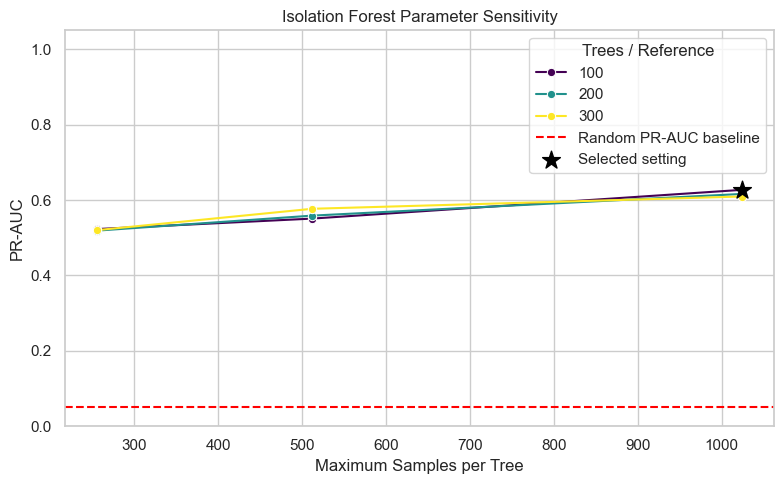

In [11]:
# Initialize shared anomaly-result containers.
anomaly_tuning_results = []
final_anomaly_models = {}
final_anomaly_scores = {}

isolation_tree_values = [100, 200, 300]
isolation_sample_values = [256, 512, 1024]

isolation_results = []

for n_estimators in isolation_tree_values:
    for max_samples in isolation_sample_values:
        start_time = time.perf_counter()

        isolation_model = IsolationForest(
            n_estimators=n_estimators,
            max_samples=max_samples,
            contamination="auto",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )

        isolation_model.fit(
            X_anomaly_train
        )

        # Negate score_samples so larger values mean more anomalous.
        anomaly_scores = -isolation_model.score_samples(
            X_anomaly_benchmark
        )

        runtime = time.perf_counter() - start_time

        metrics = calculate_anomaly_metrics(
            y_anomaly_benchmark,
            anomaly_scores,
            k=ANOMALY_K
        )

        result = {
            "Algorithm": "Isolation Forest",
            "N_Estimators": n_estimators,
            "Max_Samples": max_samples,
            **metrics,
            "Runtime": runtime
        }

        isolation_results.append(result)
        anomaly_tuning_results.append(result)

        print(
            "Completed:",
            f"trees={n_estimators},",
            f"max_samples={max_samples}"
        )

isolation_tuning_df = pd.DataFrame(
    isolation_results
)

best_isolation_row = (
    isolation_tuning_df
    .sort_values(
        [
            "PR_AUC",
            "Precision_at_k",
            "ROC_AUC",
            "Runtime"
        ],
        ascending=[False, False, False, True]
    )
    .iloc[0]
)

best_isolation_parameters = {
    "n_estimators": int(
        best_isolation_row["N_Estimators"]
    ),
    "max_samples": int(
        best_isolation_row["Max_Samples"]
    )
}

print("\nIsolation Forest tuning results:")

display(
    isolation_tuning_df.style.format({
        "Precision_at_k": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=["PR_AUC"],
        color="lightgreen"
    )
)

print(
    "\nSelected parameters:",
    best_isolation_parameters
)

# Visualize parameter sensitivity.
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=isolation_tuning_df,
    x="Max_Samples",
    y="PR_AUC",
    hue="N_Estimators",
    marker="o",
    palette="viridis"
)

plt.axhline(
    y_anomaly_benchmark.mean(),
    color="red",
    linestyle="--",
    label="Random PR-AUC baseline"
)

plt.scatter(
    best_isolation_row["Max_Samples"],
    best_isolation_row["PR_AUC"],
    color="black",
    marker="*",
    s=180,
    label="Selected setting",
    zorder=5
)

plt.ylim(0, 1.05)
plt.title("Isolation Forest Parameter Sensitivity")
plt.xlabel("Maximum Samples per Tree")
plt.ylabel("PR-AUC")
plt.legend(title="Trees / Reference")
plt.tight_layout()
plt.show()

# Refit and store the selected Isolation Forest.
best_isolation_model = IsolationForest(
    **best_isolation_parameters,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

best_isolation_model.fit(
    X_anomaly_train
)

best_isolation_scores = (
    -best_isolation_model.score_samples(
        X_anomaly_benchmark
    )
)

final_anomaly_models[
    "Isolation Forest"
] = best_isolation_model

final_anomaly_scores[
    "Isolation Forest"
] = best_isolation_scores

**Observation:** Isolation Forest performed best with 100 trees and 1,024 samples per tree, achieving Precision@k of 0.7014, ROC-AUC of 0.9818, and PR-AUC of 0.6271. Increasing the tree subsample consistently improved PR-AUC, while increasing the number of trees beyond 100 provided no additional benefit and increased runtime.

#### 4.4.2 One-Class SVM

One-Class SVM estimates a boundary around normal training observations. Using the RBF kernel, its decision function is:

$$
f(x)=\sum_i \alpha_i
\exp\left(-\gamma\lVert x_i-x\rVert^2\right)-\rho
$$

Observations outside the learned boundary receive lower decision values and are treated as anomalies.

The parameter `nu` controls the allowed proportion of training observations outside the boundary, while `gamma` controls the locality and flexibility of the RBF decision surface. Large gamma values create tighter and more complex boundaries, increasing the risk of labelling normal variation as anomalous.

Completed: nu=0.01, gamma=scale
Completed: nu=0.01, gamma=0.01
Completed: nu=0.01, gamma=0.10
Completed: nu=0.05, gamma=scale
Completed: nu=0.05, gamma=0.01
Completed: nu=0.05, gamma=0.10
Completed: nu=0.1, gamma=scale
Completed: nu=0.1, gamma=0.01
Completed: nu=0.1, gamma=0.10

One-Class SVM tuning results:


,Algorithm,Nu,Gamma,Precision_at_k,ROC_AUC,PR_AUC,Runtime
0,One-Class SVM,0.01,scale,0.1848,0.5931,0.1143,0.1214
1,One-Class SVM,0.01,0.01,0.5213,0.9749,0.4600,2.8832
2,One-Class SVM,0.01,0.10,0.5118,0.9750,0.4608,2.8188
3,One-Class SVM,0.05,scale,0.0948,0.5945,0.0968,0.4980
4,One-Class SVM,0.05,0.01,0.5213,0.9749,0.4599,1.8104
5,One-Class SVM,0.05,0.10,0.5118,0.9750,0.4608,1.4604
6,One-Class SVM,0.10,scale,0.0379,0.6048,0.0899,0.6386
7,One-Class SVM,0.10,0.01,0.5118,0.9737,0.4497,0.9561
8,One-Class SVM,0.10,0.10,0.5118,0.9750,0.4608,1.3185



Selected parameters: {'nu': 0.05, 'gamma': 0.1}


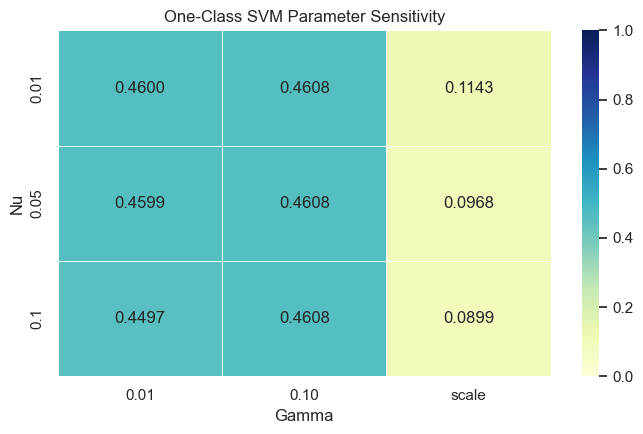

In [12]:
# Systematically tune One-Class SVM.
ocsvm_nu_values = [0.01, 0.05, 0.10]

ocsvm_gamma_options = [
    ("scale", "scale"),
    ("0.01", 0.01),
    ("0.10", 0.10)
]

ocsvm_results = []

for nu_value in ocsvm_nu_values:
    for gamma_label, gamma_value in (
        ocsvm_gamma_options
    ):
        start_time = time.perf_counter()

        ocsvm_model = OneClassSVM(
            kernel="rbf",
            nu=nu_value,
            gamma=gamma_value,
            cache_size=1000,
            tol=1e-3
        )

        ocsvm_model.fit(
            X_anomaly_train
        )

        # Negative margin gives a higher score for anomalies.
        anomaly_scores = (
            -ocsvm_model.decision_function(
                X_anomaly_benchmark
            ).ravel()
        )

        runtime = time.perf_counter() - start_time

        metrics = calculate_anomaly_metrics(
            y_anomaly_benchmark,
            anomaly_scores,
            k=ANOMALY_K
        )

        result = {
            "Algorithm": "One-Class SVM",
            "Nu": nu_value,
            "Gamma": gamma_label,
            **metrics,
            "Runtime": runtime
        }

        ocsvm_results.append(result)
        anomaly_tuning_results.append(result)

        print(
            "Completed:",
            f"nu={nu_value},",
            f"gamma={gamma_label}"
        )

ocsvm_tuning_df = pd.DataFrame(
    ocsvm_results
)

best_ocsvm_row = (
    ocsvm_tuning_df
    .sort_values(
        [
            "PR_AUC",
            "Precision_at_k",
            "ROC_AUC",
            "Runtime"
        ],
        ascending=[False, False, False, True]
    )
    .iloc[0]
)

selected_gamma_label = best_ocsvm_row["Gamma"]

selected_gamma_value = (
    "scale"
    if selected_gamma_label == "scale"
    else float(selected_gamma_label)
)

best_ocsvm_parameters = {
    "nu": float(best_ocsvm_row["Nu"]),
    "gamma": selected_gamma_value
}

print("\nOne-Class SVM tuning results:")

display(
    ocsvm_tuning_df.style.format({
        "Nu": "{:.2f}",
        "Precision_at_k": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=["PR_AUC"],
        color="lightgreen"
    )
)

print(
    "\nSelected parameters:",
    best_ocsvm_parameters
)

# Visualize parameter sensitivity.
ocsvm_sensitivity_matrix = (
    ocsvm_tuning_df.pivot(
        index="Nu",
        columns="Gamma",
        values="PR_AUC"
    )
)

plt.figure(figsize=(7, 4.5))

sns.heatmap(
    ocsvm_sensitivity_matrix,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("One-Class SVM Parameter Sensitivity")
plt.xlabel("Gamma")
plt.ylabel("Nu")
plt.tight_layout()
plt.show()

# Refit and store the selected One-Class SVM.
best_ocsvm_model = OneClassSVM(
    kernel="rbf",
    **best_ocsvm_parameters,
    cache_size=1000,
    tol=1e-3
)

best_ocsvm_model.fit(
    X_anomaly_train
)

best_ocsvm_scores = (
    -best_ocsvm_model.decision_function(
        X_anomaly_benchmark
    ).ravel()
)

final_anomaly_models[
    "One-Class SVM"
] = best_ocsvm_model

final_anomaly_scores[
    "One-Class SVM"
] = best_ocsvm_scores

**Observation:** One-Class SVM selected `nu = 0.05` and `gamma = 0.10`, producing Precision@k of 0.5118, ROC-AUC of 0.9750, and PR-AUC of 0.4608. Fixed gamma values strongly outperformed the automatically scaled value. The automatic value created an excessively smooth boundary for the robust-scaled sensor distribution, while gamma values of 0.01 and 0.10 captured more useful local structure. Performance was comparatively insensitive to `nu`.

#### 4.4.3 Local Outlier Factor

Local Outlier Factor compares the density surrounding an observation with the densities surrounding its nearest neighbours.

For observation \(x\), local reachability density is:

$$
LRD_k(x)=
\left(
\frac{1}{|N_k(x)|}
\sum_{o\in N_k(x)}
\max\{d_k(o),d(x,o)\}
\right)^{-1}
$$

The LOF score is:

$$
LOF_k(x)=
\frac{1}{|N_k(x)|}
\sum_{o\in N_k(x)}
\frac{LRD_k(o)}{LRD_k(x)}
$$

Values substantially greater than one indicate that an observation has lower local density than its neighbours.

The experiment compares several neighbourhood sizes using both Euclidean and Manhattan distance. Small neighbourhoods detect highly local irregularities but can be unstable, while large neighbourhoods produce smoother density estimates that may miss small anomaly groups.

Completed: metric=euclidean, neighbors=10
Completed: metric=euclidean, neighbors=20
Completed: metric=euclidean, neighbors=35
Completed: metric=euclidean, neighbors=50
Completed: metric=euclidean, neighbors=75
Completed: metric=manhattan, neighbors=10
Completed: metric=manhattan, neighbors=20
Completed: metric=manhattan, neighbors=35
Completed: metric=manhattan, neighbors=50
Completed: metric=manhattan, neighbors=75

Local Outlier Factor tuning results:


,Algorithm,N_Neighbors,Distance_Metric,Precision_at_k,ROC_AUC,PR_AUC,Runtime
0,Local Outlier Factor,10,euclidean,0.8246,0.9267,0.7334,11.4366
1,Local Outlier Factor,20,euclidean,0.7915,0.8916,0.5637,0.3564
2,Local Outlier Factor,35,euclidean,0.8104,0.8791,0.6448,0.4125
3,Local Outlier Factor,50,euclidean,0.8057,0.8730,0.7780,0.5235
4,Local Outlier Factor,75,euclidean,0.8199,0.8816,0.7760,0.5234
5,Local Outlier Factor,10,manhattan,0.8436,0.9674,0.6923,1.3728
6,Local Outlier Factor,20,manhattan,0.7915,0.9351,0.5542,1.3781
7,Local Outlier Factor,35,manhattan,0.8199,0.9224,0.6377,1.4889
8,Local Outlier Factor,50,manhattan,0.8246,0.9098,0.6589,1.5933
9,Local Outlier Factor,75,manhattan,0.6066,0.8963,0.4168,1.5990



Selected parameters: {'n_neighbors': 50, 'metric': 'euclidean'}


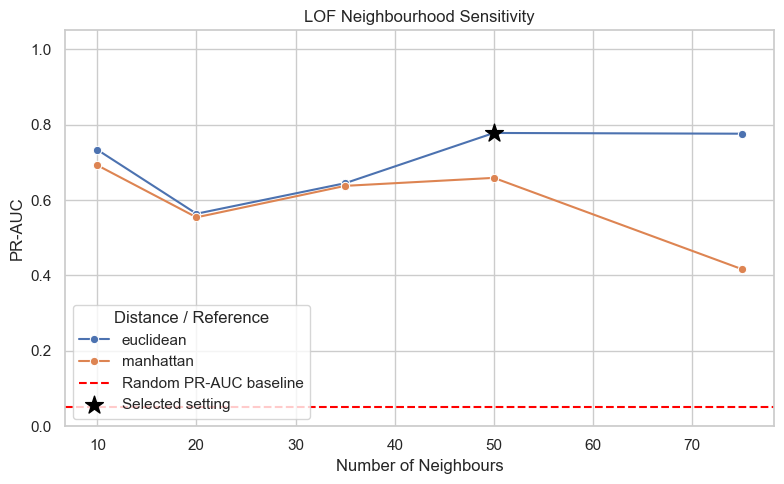

In [13]:
# Systematically tune Local Outlier Factor in novelty mode.
lof_neighbor_values = [10, 20, 35, 50, 75]
lof_metric_values = ["euclidean", "manhattan"]

lof_results = []

for distance_metric in lof_metric_values:
    for n_neighbors in lof_neighbor_values:
        start_time = time.perf_counter()

        lof_model = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            metric=distance_metric,
            contamination="auto",
            novelty=True,
            n_jobs=-1
        )

        lof_model.fit(
            X_anomaly_train
        )

        # Negative score gives higher values for anomalies.
        anomaly_scores = (
            -lof_model.score_samples(
                X_anomaly_benchmark
            )
        )

        runtime = time.perf_counter() - start_time

        metrics = calculate_anomaly_metrics(
            y_anomaly_benchmark,
            anomaly_scores,
            k=ANOMALY_K
        )

        result = {
            "Algorithm": "Local Outlier Factor",
            "N_Neighbors": n_neighbors,
            "Distance_Metric": distance_metric,
            **metrics,
            "Runtime": runtime
        }

        lof_results.append(result)
        anomaly_tuning_results.append(result)

        print(
            "Completed:",
            f"metric={distance_metric},",
            f"neighbors={n_neighbors}"
        )

lof_tuning_df = pd.DataFrame(
    lof_results
)

best_lof_row = (
    lof_tuning_df
    .sort_values(
        [
            "PR_AUC",
            "Precision_at_k",
            "ROC_AUC",
            "Runtime"
        ],
        ascending=[False, False, False, True]
    )
    .iloc[0]
)

best_lof_parameters = {
    "n_neighbors": int(
        best_lof_row["N_Neighbors"]
    ),
    "metric": best_lof_row[
        "Distance_Metric"
    ]
}

print("\nLocal Outlier Factor tuning results:")

display(
    lof_tuning_df.style.format({
        "Precision_at_k": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=["PR_AUC"],
        color="lightgreen"
    )
)

print(
    "\nSelected parameters:",
    best_lof_parameters
)

# Visualize neighbourhood sensitivity.
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=lof_tuning_df,
    x="N_Neighbors",
    y="PR_AUC",
    hue="Distance_Metric",
    marker="o"
)

plt.axhline(
    y_anomaly_benchmark.mean(),
    color="red",
    linestyle="--",
    label="Random PR-AUC baseline"
)

plt.scatter(
    best_lof_row["N_Neighbors"],
    best_lof_row["PR_AUC"],
    color="black",
    marker="*",
    s=180,
    label="Selected setting",
    zorder=5
)

plt.ylim(0, 1.05)
plt.title("LOF Neighbourhood Sensitivity")
plt.xlabel("Number of Neighbours")
plt.ylabel("PR-AUC")
plt.legend(title="Distance / Reference")
plt.tight_layout()
plt.show()

# Refit and store the selected LOF model.
best_lof_model = LocalOutlierFactor(
    **best_lof_parameters,
    contamination="auto",
    novelty=True,
    n_jobs=-1
)

best_lof_model.fit(
    X_anomaly_train
)

best_lof_scores = (
    -best_lof_model.score_samples(
        X_anomaly_benchmark
    )
)

final_anomaly_models[
    "Local Outlier Factor"
] = best_lof_model

final_anomaly_scores[
    "Local Outlier Factor"
] = best_lof_scores

**Observation:** LOF selected 50 Euclidean neighbours and achieved Precision@k of 0.8057 and PR-AUC of 0.7780, outperforming both Isolation Forest and One-Class SVM on the primary metric. Performance changed non-monotonically with neighbourhood size, confirming that LOF is sensitive to the scale at which local density is measured. Manhattan distance performed best with 10 neighbours but deteriorated substantially at 75 neighbours.

#### 4.4.4 Elliptic Envelope

Elliptic Envelope models normal observations using a robust multivariate Gaussian distribution. An observation's squared Mahalanobis distance is:

$$
d_M^2(x)=(x-\mu)^T\Sigma^{-1}(x-\mu)
$$

where \(\mu\) is the robust location estimate and \(\Sigma\) is the robust covariance matrix. Large distances indicate observations lying outside the estimated normal ellipse.

The Minimum Covariance Determinant estimator fits location and covariance using a resistant subset of the training data. `support_fraction` controls the proportion used for this robust estimate. `assume_centered` tests whether fixing the centre near zero is appropriate after robust scaling.

The method may struggle when the data are strongly non-Gaussian, multimodal, or highly correlated.

Completed: support=0.6, centered=False
Completed: support=0.6, centered=True
Completed: support=0.75, centered=False
Completed: support=0.75, centered=True
Completed: support=0.9, centered=False
Completed: support=0.9, centered=True

Elliptic Envelope tuning results:


,Algorithm,Support_Fraction,Assume_Centered,Precision_at_k,ROC_AUC,PR_AUC,Runtime
0,Elliptic Envelope,0.60,False,0.9858,0.9993,0.9934,3.9737
1,Elliptic Envelope,0.60,True,0.9336,0.9988,0.9864,2.4071
2,Elliptic Envelope,0.75,False,0.9336,0.9978,0.9740,2.8536
3,Elliptic Envelope,0.75,True,0.9479,0.9985,0.9818,2.6814
4,Elliptic Envelope,0.90,False,0.9242,0.9980,0.9731,2.4807
5,Elliptic Envelope,0.90,True,0.9384,0.9981,0.9761,2.8283



Selected parameters: {'support_fraction': 0.6, 'assume_centered': False}


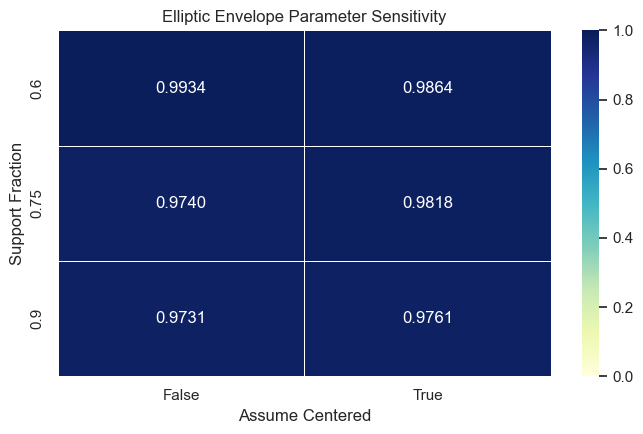

In [14]:
# Systematically tune Elliptic Envelope.
elliptic_support_values = [0.60, 0.75, 0.90]
elliptic_center_values = [False, True]

elliptic_results = []

for support_fraction in elliptic_support_values:
    for assume_centered in elliptic_center_values:
        start_time = time.perf_counter()

        try:
            elliptic_model = EllipticEnvelope(
                support_fraction=support_fraction,
                contamination=(
                    SYNTHETIC_ANOMALY_FRACTION
                ),
                assume_centered=assume_centered,
                random_state=RANDOM_STATE
            )

            elliptic_model.fit(
                X_anomaly_train
            )

            anomaly_scores = (
                -elliptic_model.score_samples(
                    X_anomaly_benchmark
                )
            )

            runtime = (
                time.perf_counter()
                - start_time
            )

            metrics = calculate_anomaly_metrics(
                y_anomaly_benchmark,
                anomaly_scores,
                k=ANOMALY_K
            )

            result = {
                "Algorithm": "Elliptic Envelope",
                "Support_Fraction": support_fraction,
                "Assume_Centered": assume_centered,
                **metrics,
                "Runtime": runtime
            }

            elliptic_results.append(result)
            anomaly_tuning_results.append(result)

            print(
                "Completed:",
                f"support={support_fraction},",
                f"centered={assume_centered}"
            )

        except Exception as error:
            print(
                "Failed:",
                f"support={support_fraction},",
                f"centered={assume_centered},",
                str(error)
            )

elliptic_tuning_df = pd.DataFrame(
    elliptic_results
)

if elliptic_tuning_df.empty:
    raise RuntimeError(
        "All Elliptic Envelope configurations failed."
    )

best_elliptic_row = (
    elliptic_tuning_df
    .sort_values(
        [
            "PR_AUC",
            "Precision_at_k",
            "ROC_AUC",
            "Runtime"
        ],
        ascending=[False, False, False, True]
    )
    .iloc[0]
)

best_elliptic_parameters = {
    "support_fraction": float(
        best_elliptic_row[
            "Support_Fraction"
        ]
    ),
    "assume_centered": bool(
        best_elliptic_row[
            "Assume_Centered"
        ]
    )
}

print("\nElliptic Envelope tuning results:")

display(
    elliptic_tuning_df.style.format({
        "Support_Fraction": "{:.2f}",
        "Precision_at_k": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=["PR_AUC"],
        color="lightgreen"
    )
)

print(
    "\nSelected parameters:",
    best_elliptic_parameters
)

# Visualize covariance-estimation sensitivity.
elliptic_sensitivity_matrix = (
    elliptic_tuning_df.pivot(
        index="Support_Fraction",
        columns="Assume_Centered",
        values="PR_AUC"
    )
)

plt.figure(figsize=(7, 4.5))

sns.heatmap(
    elliptic_sensitivity_matrix,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Elliptic Envelope Parameter Sensitivity")
plt.xlabel("Assume Centered")
plt.ylabel("Support Fraction")
plt.tight_layout()
plt.show()

# Refit and store the selected Elliptic Envelope.
best_elliptic_model = EllipticEnvelope(
    **best_elliptic_parameters,
    contamination=SYNTHETIC_ANOMALY_FRACTION,
    random_state=RANDOM_STATE
)

best_elliptic_model.fit(
    X_anomaly_train
)

best_elliptic_scores = (
    -best_elliptic_model.score_samples(
        X_anomaly_benchmark
    )
)

final_anomaly_models[
    "Elliptic Envelope"
] = best_elliptic_model

final_anomaly_scores[
    "Elliptic Envelope"
] = best_elliptic_scores

**Observation:** Elliptic Envelope selected a support fraction of 0.60 without assuming a fixed zero centre. It achieved Precision@k of 0.9858, ROC-AUC of 0.9993, and PR-AUC of 0.9934. The result indicates that the synthetic perturbations are strongly separated under robust covariance distance. However, this near-perfect synthetic performance does not guarantee equivalent detection of real failure behaviour, which may be nonlinear, multimodal, or less extreme.

#### 4.4.5 Autoencoder Reconstruction Error

An autoencoder learns to reproduce normal input observations through a lower-dimensional bottleneck:

$$
z=f_{\theta}(x)
$$

$$
\hat{x}=g_{\phi}(z)
$$

Its reconstruction loss is:

$$
L(x,\hat{x})=
\frac{1}{p}
\sum_{j=1}^{p}(x_j-\hat{x}_j)^2
$$

The model is trained only on weak-normal reference windows. Observations that differ from learned normal patterns should produce larger reconstruction errors.

The bottleneck dimension controls compression strength, while `alpha` applies L2 regularization. A very small bottleneck may underfit normal patterns, whereas a large bottleneck may reconstruct anomalies too accurately.

Robust-scaled values are clipped to \([-20,20]\) only for neural-network stability. The same clipping is applied to training and evaluation data. The framework restriction in Part 3 applied to the dimensionality-reduction autoencoder already implemented from scratch; the anomaly-detection autoencoder may use a neural-network library.

Completed: bottleneck=4, alpha=0.0001, epochs=198
Completed: bottleneck=4, alpha=0.001, epochs=94
Completed: bottleneck=8, alpha=0.0001, epochs=250
Completed: bottleneck=8, alpha=0.001, epochs=222
Completed: bottleneck=12, alpha=0.0001, epochs=248
Completed: bottleneck=12, alpha=0.001, epochs=227

Autoencoder tuning results:


,Algorithm,Bottleneck_Size,Alpha,Training_Epochs,Precision_at_k,ROC_AUC,PR_AUC,Runtime
0,Autoencoder,4,0.0001,198,1.0000,1.0000,1.0000,10.6749
1,Autoencoder,4,0.0010,94,0.9905,1.0000,0.9998,4.1777
2,Autoencoder,8,0.0001,250,0.9953,1.0000,1.0000,10.8272
3,Autoencoder,8,0.0010,222,1.0000,1.0000,1.0000,9.9934
4,Autoencoder,12,0.0001,248,1.0000,1.0000,1.0000,10.8248
5,Autoencoder,12,0.0010,227,1.0000,1.0000,1.0000,9.9435



Selected parameters: {'bottleneck_size': 12, 'alpha': 0.001}


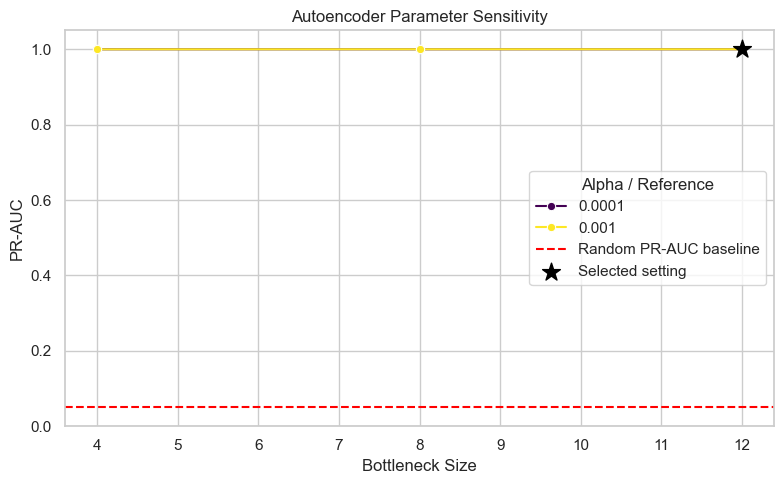

In [15]:
# Prepare bounded inputs for stable autoencoder training.
AUTOENCODER_CLIP_LIMIT = 20.0

X_autoencoder_train = np.clip(
    X_anomaly_train,
    -AUTOENCODER_CLIP_LIMIT,
    AUTOENCODER_CLIP_LIMIT
)

X_autoencoder_benchmark = np.clip(
    X_anomaly_benchmark,
    -AUTOENCODER_CLIP_LIMIT,
    AUTOENCODER_CLIP_LIMIT
)

autoencoder_bottleneck_values = [4, 8, 12]
autoencoder_alpha_values = [0.0001, 0.001]

autoencoder_results = []

for bottleneck_size in (
    autoencoder_bottleneck_values
):
    for alpha_value in autoencoder_alpha_values:
        start_time = time.perf_counter()

        autoencoder_model = MLPRegressor(
            hidden_layer_sizes=(
                24,
                bottleneck_size,
                24
            ),
            activation="relu",
            solver="adam",
            alpha=alpha_value,
            batch_size=128,
            learning_rate_init=0.001,
            max_iter=250,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=15,
            random_state=RANDOM_STATE
        )

        # Autoencoder target is identical to its input.
        autoencoder_model.fit(
            X_autoencoder_train,
            X_autoencoder_train
        )

        reconstructed_values = (
            autoencoder_model.predict(
                X_autoencoder_benchmark
            )
        )

        anomaly_scores = np.mean(
            (
                X_autoencoder_benchmark
                - reconstructed_values
            ) ** 2,
            axis=1
        )

        runtime = time.perf_counter() - start_time

        metrics = calculate_anomaly_metrics(
            y_anomaly_benchmark,
            anomaly_scores,
            k=ANOMALY_K
        )

        result = {
            "Algorithm": "Autoencoder",
            "Bottleneck_Size": bottleneck_size,
            "Alpha": alpha_value,
            "Training_Epochs": (
                autoencoder_model.n_iter_
            ),
            **metrics,
            "Runtime": runtime
        }

        autoencoder_results.append(result)
        anomaly_tuning_results.append(result)

        print(
            "Completed:",
            f"bottleneck={bottleneck_size},",
            f"alpha={alpha_value},",
            f"epochs={autoencoder_model.n_iter_}"
        )

autoencoder_tuning_df = pd.DataFrame(
    autoencoder_results
)

best_autoencoder_row = (
    autoencoder_tuning_df
    .sort_values(
        [
            "PR_AUC",
            "Precision_at_k",
            "ROC_AUC",
            "Runtime"
        ],
        ascending=[False, False, False, True]
    )
    .iloc[0]
)

best_autoencoder_parameters = {
    "bottleneck_size": int(
        best_autoencoder_row[
            "Bottleneck_Size"
        ]
    ),
    "alpha": float(
        best_autoencoder_row["Alpha"]
    )
}

print("\nAutoencoder tuning results:")

display(
    autoencoder_tuning_df.style.format({
        "Alpha": "{:.4f}",
        "Precision_at_k": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=["PR_AUC"],
        color="lightgreen"
    )
)

print(
    "\nSelected parameters:",
    best_autoencoder_parameters
)

# Visualize bottleneck and regularization sensitivity.
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=autoencoder_tuning_df,
    x="Bottleneck_Size",
    y="PR_AUC",
    hue="Alpha",
    marker="o",
    palette="viridis"
)

plt.axhline(
    y_anomaly_benchmark.mean(),
    color="red",
    linestyle="--",
    label="Random PR-AUC baseline"
)

plt.scatter(
    best_autoencoder_row[
        "Bottleneck_Size"
    ],
    best_autoencoder_row["PR_AUC"],
    color="black",
    marker="*",
    s=180,
    label="Selected setting",
    zorder=5
)

plt.ylim(0, 1.05)
plt.title("Autoencoder Parameter Sensitivity")
plt.xlabel("Bottleneck Size")
plt.ylabel("PR-AUC")
plt.legend(title="Alpha / Reference")
plt.tight_layout()
plt.show()

# Refit and store the selected autoencoder.
best_autoencoder_model = MLPRegressor(
    hidden_layer_sizes=(
        24,
        best_autoencoder_parameters[
            "bottleneck_size"
        ],
        24
    ),
    activation="relu",
    solver="adam",
    alpha=best_autoencoder_parameters["alpha"],
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=250,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

best_autoencoder_model.fit(
    X_autoencoder_train,
    X_autoencoder_train
)

best_autoencoder_reconstruction = (
    best_autoencoder_model.predict(
        X_autoencoder_benchmark
    )
)

best_autoencoder_scores = np.mean(
    (
        X_autoencoder_benchmark
        - best_autoencoder_reconstruction
    ) ** 2,
    axis=1
)

final_anomaly_models[
    "Autoencoder"
] = best_autoencoder_model

final_anomaly_scores[
    "Autoencoder"
] = best_autoencoder_scores

**Observation:** All autoencoder configurations separated the injected anomalies extremely well. The selected architecture used a 12-unit bottleneck with `alpha = 0.001`, achieving perfect reported metrics. The similar results across bottleneck sizes indicate that the injected abnormalities produce reconstruction patterns far outside those learned from weak-normal training data. These synthetic results should not be interpreted as guaranteed perfect detection of real maintenance failures.

#### 4.4.6 DBSCAN-Based Noise Detection

DBSCAN defines an observation as a core point when at least `min_samples` observations occur within radius \(\varepsilon\). Observations that are not density-reachable from any core point are labelled as noise.

The distance to the `min_samples`-th nearest neighbour is used to construct data-dependent epsilon candidates. DBSCAN noise status is combined with this distance to create a continuous ranking score: noise observations rank above non-noise observations, while greater neighbourhood distance indicates greater abnormality within each group.

Epsilon candidates are generated from several quantiles of the benchmark's neighbourhood-distance distribution. This avoids arbitrary manual values and permits systematic sensitivity analysis.

Completed: min_samples=5, quantile=0.850, eps=7.3423
Completed: min_samples=5, quantile=0.900, eps=12.0849
Completed: min_samples=5, quantile=0.950, eps=14.9868
Completed: min_samples=5, quantile=0.975, eps=19.8818
Completed: min_samples=10, quantile=0.850, eps=12.3427
Completed: min_samples=10, quantile=0.900, eps=16.8243
Completed: min_samples=10, quantile=0.950, eps=30.7438
Completed: min_samples=10, quantile=0.975, eps=41.6729
Completed: min_samples=20, quantile=0.850, eps=13.9712
Completed: min_samples=20, quantile=0.900, eps=37.6105
Completed: min_samples=20, quantile=0.950, eps=60.5372
Completed: min_samples=20, quantile=0.975, eps=74.0915

DBSCAN tuning results:


,Algorithm,Min_Samples,Epsilon_Quantile,Epsilon,Clusters,Noise_Fraction,Precision_at_k,ROC_AUC,PR_AUC,Runtime
0,DBSCAN,5,0.850,7.3423,25,0.1330,0.1754,0.9482,0.3024,0.9288
1,DBSCAN,5,0.900,12.0849,28,0.0841,0.2180,0.9529,0.3234,4.2634
2,DBSCAN,5,0.950,14.9868,34,0.0309,0.1754,0.9484,0.3030,1.7722
3,DBSCAN,5,0.975,19.8818,21,0.0185,0.1754,0.9479,0.3014,1.6708
4,DBSCAN,10,0.850,12.3427,10,0.1297,0.0521,0.8996,0.1894,0.9234
5,DBSCAN,10,0.900,16.8243,10,0.0848,0.0521,0.8939,0.1814,0.9624
6,DBSCAN,10,0.950,30.7438,13,0.0268,0.0521,0.8939,0.1815,0.8646
7,DBSCAN,10,0.975,41.6729,5,0.0190,0.0521,0.8939,0.1815,0.8931
8,DBSCAN,20,0.850,13.9712,2,0.1408,0.0521,0.8712,0.1553,0.8295
9,DBSCAN,20,0.900,37.6105,5,0.0777,0.0521,0.8707,0.1550,0.9147



Selected parameters: {'eps': 12.084891861571691, 'min_samples': 5}


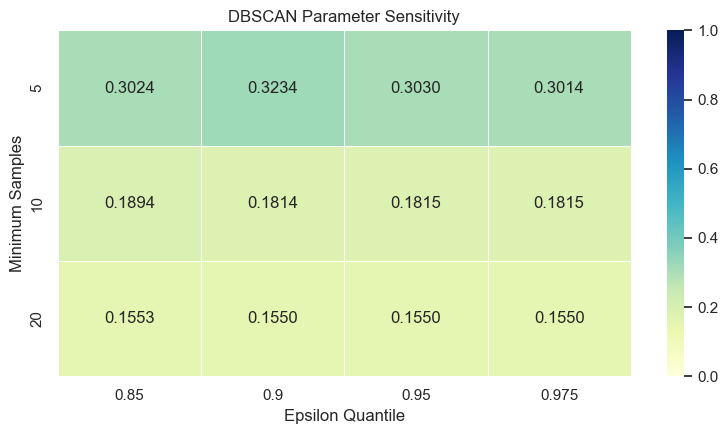

In [16]:
# Additional utility required for DBSCAN parameter estimation.
from sklearn.neighbors import NearestNeighbors

dbscan_min_samples_values = [5, 10, 20]
dbscan_epsilon_quantiles = [0.85, 0.90, 0.95, 0.975]

dbscan_results = []
dbscan_score_store = {}
dbscan_label_store = {}

for min_samples_value in dbscan_min_samples_values:
    # Estimate density scale using k-nearest-neighbour distances.
    neighbor_model = NearestNeighbors(
        n_neighbors=min_samples_value,
        metric="euclidean",
        n_jobs=-1
    )

    neighbor_model.fit(X_anomaly_benchmark)

    neighbor_distances, _ = (
        neighbor_model.kneighbors(
            X_anomaly_benchmark
        )
    )

    kth_neighbor_distance = (
        neighbor_distances[:, -1]
    )

    epsilon_candidates = np.quantile(
        kth_neighbor_distance,
        dbscan_epsilon_quantiles
    )

    for epsilon_quantile, epsilon_value in zip(
        dbscan_epsilon_quantiles,
        epsilon_candidates
    ):
        start_time = time.perf_counter()

        dbscan_model = DBSCAN(
            eps=float(epsilon_value),
            min_samples=min_samples_value,
            metric="euclidean",
            n_jobs=-1
        )

        dbscan_labels = dbscan_model.fit_predict(
            X_anomaly_benchmark
        )

        noise_mask = dbscan_labels == -1

        # Noise points rank above non-noise points.
        score_bonus = (
            np.max(kth_neighbor_distance) + 1.0
        )

        anomaly_scores = (
            kth_neighbor_distance
            + noise_mask.astype(float)
            * score_bonus
        )

        runtime = time.perf_counter() - start_time

        metrics = calculate_anomaly_metrics(
            y_anomaly_benchmark,
            anomaly_scores,
            k=ANOMALY_K
        )

        result = {
            "Algorithm": "DBSCAN",
            "Min_Samples": min_samples_value,
            "Epsilon_Quantile": epsilon_quantile,
            "Epsilon": float(epsilon_value),
            "Clusters": len(
                set(dbscan_labels) - {-1}
            ),
            "Noise_Fraction": float(
                noise_mask.mean()
            ),
            **metrics,
            "Runtime": runtime
        }

        result_key = (
            min_samples_value,
            epsilon_quantile
        )

        dbscan_results.append(result)
        anomaly_tuning_results.append(result)

        dbscan_score_store[result_key] = (
            anomaly_scores
        )

        dbscan_label_store[result_key] = (
            dbscan_labels
        )

        print(
            "Completed:",
            f"min_samples={min_samples_value},",
            f"quantile={epsilon_quantile:.3f},",
            f"eps={epsilon_value:.4f}"
        )

dbscan_tuning_df = pd.DataFrame(
    dbscan_results
)

best_dbscan_row = (
    dbscan_tuning_df
    .sort_values(
        [
            "PR_AUC",
            "Precision_at_k",
            "ROC_AUC",
            "Runtime"
        ],
        ascending=[False, False, False, True]
    )
    .iloc[0]
)

best_dbscan_key = (
    int(best_dbscan_row["Min_Samples"]),
    float(best_dbscan_row["Epsilon_Quantile"])
)

best_dbscan_parameters = {
    "eps": float(best_dbscan_row["Epsilon"]),
    "min_samples": int(
        best_dbscan_row["Min_Samples"]
    )
}

print("\nDBSCAN tuning results:")

display(
    dbscan_tuning_df.style.format({
        "Epsilon_Quantile": "{:.3f}",
        "Epsilon": "{:.4f}",
        "Noise_Fraction": "{:.4f}",
        "Precision_at_k": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=["PR_AUC"],
        color="lightgreen"
    )
)

print(
    "\nSelected parameters:",
    best_dbscan_parameters
)

# Visualize DBSCAN parameter sensitivity.
dbscan_sensitivity_matrix = (
    dbscan_tuning_df.pivot(
        index="Min_Samples",
        columns="Epsilon_Quantile",
        values="PR_AUC"
    )
)

plt.figure(figsize=(8, 4.5))

sns.heatmap(
    dbscan_sensitivity_matrix,
    annot=True,
    fmt=".4f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("DBSCAN Parameter Sensitivity")
plt.xlabel("Epsilon Quantile")
plt.ylabel("Minimum Samples")
plt.tight_layout()
plt.show()

# Refit and store the selected DBSCAN configuration.
best_dbscan_model = DBSCAN(
    **best_dbscan_parameters,
    metric="euclidean",
    n_jobs=-1
)

best_dbscan_labels = (
    best_dbscan_model.fit_predict(
        X_anomaly_benchmark
    )
)

best_dbscan_scores = dbscan_score_store[
    best_dbscan_key
]

final_anomaly_models[
    "DBSCAN"
] = best_dbscan_model

final_anomaly_scores[
    "DBSCAN"
] = best_dbscan_scores

**Observation:** DBSCAN performed best with `min_samples = 5` and an epsilon of 12.0849, derived from the 90th percentile of neighbourhood distances. It achieved ROC-AUC of 0.9529 but only PR-AUC of 0.3234 and Precision@k of 0.2180. This difference demonstrates why ROC-AUC alone can appear optimistic under class imbalance. Larger `min_samples` values substantially reduced performance because the heterogeneous operating modes do not share a single uniform density.

#### 4.4.7 Histogram-Based Outlier Score

HBOS models each feature independently using a histogram. For feature \(j\), the probability of the bin containing value \(x_j\) is estimated from normal training observations. The total anomaly score is:

$$
HBOS(x)=
\sum_{j=1}^{p}
-\log\left(\hat{p}_j(x_j)+\epsilon\right)
$$

Rare feature values produce small estimated probabilities and therefore larger anomaly scores. Values outside the training range receive the smoothed minimum probability.

HBOS is computationally efficient and does not require pairwise distances. However, its feature-independence assumption means it may miss anomalies that are unusual only because of interactions between sensors.

The number of bins controls histogram resolution. Too few bins hide local irregularities, while too many bins create sparse and unstable estimates. Additive smoothing prevents empty bins from producing infinite scores.

Completed: bins=10, smoothing=0.1
Completed: bins=10, smoothing=1.0
Completed: bins=20, smoothing=0.1
Completed: bins=20, smoothing=1.0
Completed: bins=30, smoothing=0.1
Completed: bins=30, smoothing=1.0
Completed: bins=50, smoothing=0.1
Completed: bins=50, smoothing=1.0

HBOS tuning results:


,Algorithm,N_Bins,Smoothing,Precision_at_k,ROC_AUC,PR_AUC,Runtime
0,HBOS,10,0.1,0.8863,0.9973,0.9436,0.0187
1,HBOS,10,1.0,0.7915,0.9950,0.8951,0.0186
2,HBOS,20,0.1,0.8199,0.9954,0.9034,0.0163
3,HBOS,20,1.0,0.7630,0.9923,0.8424,0.0184
4,HBOS,30,0.1,0.8104,0.9944,0.8834,0.0204
5,HBOS,30,1.0,0.7393,0.9899,0.8075,0.0159
6,HBOS,50,0.1,0.8009,0.9933,0.8549,0.0277
7,HBOS,50,1.0,0.7299,0.9872,0.7702,0.0179



Selected parameters: {'n_bins': 10, 'smoothing': 0.1}


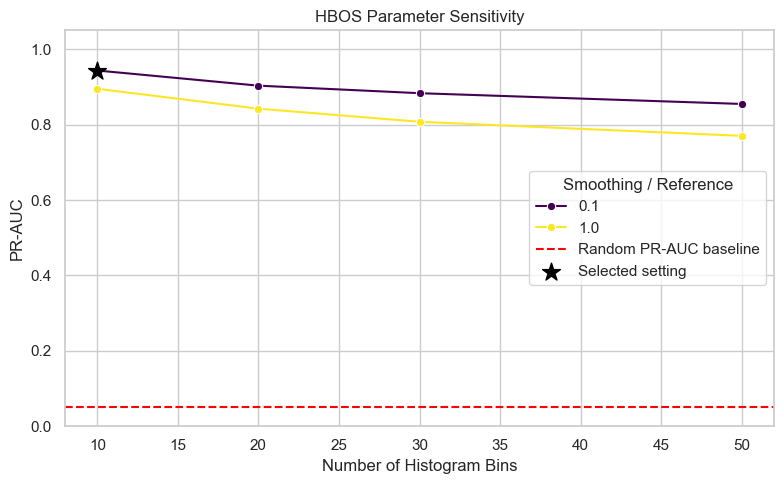

In [17]:
# Implement Histogram-Based Outlier Score without an external package.
def fit_hbos(
    X_train,
    n_bins=20,
    smoothing=0.1
):
    X_train = np.asarray(
        X_train,
        dtype=float
    )

    feature_histograms = []

    for feature_index in range(
        X_train.shape[1]
    ):
        feature_values = X_train[
            :,
            feature_index
        ]

        counts, bin_edges = np.histogram(
            feature_values,
            bins=n_bins
        )

        denominator = (
            len(feature_values)
            + smoothing * n_bins
        )

        bin_probabilities = (
            counts + smoothing
        ) / denominator

        outside_probability = (
            smoothing / denominator
        )

        feature_histograms.append({
            "Bin_Edges": bin_edges,
            "Bin_Probabilities": (
                bin_probabilities
            ),
            "Outside_Probability": (
                outside_probability
            )
        })

    return {
        "N_Bins": n_bins,
        "Smoothing": smoothing,
        "Feature_Histograms": (
            feature_histograms
        )
    }


def score_hbos(
    hbos_model,
    X
):
    X = np.asarray(X, dtype=float)

    anomaly_scores = np.zeros(
        len(X),
        dtype=float
    )

    for feature_index, histogram in enumerate(
        hbos_model["Feature_Histograms"]
    ):
        feature_values = X[
            :,
            feature_index
        ]

        bin_edges = histogram["Bin_Edges"]
        bin_probabilities = histogram[
            "Bin_Probabilities"
        ]

        bin_indices = (
            np.searchsorted(
                bin_edges,
                feature_values,
                side="right"
            )
            - 1
        )

        outside_mask = (
            (feature_values < bin_edges[0])
            | (feature_values > bin_edges[-1])
        )

        valid_indices = np.clip(
            bin_indices,
            0,
            len(bin_probabilities) - 1
        )

        probabilities = (
            bin_probabilities[
                valid_indices
            ].copy()
        )

        probabilities[outside_mask] = (
            histogram[
                "Outside_Probability"
            ]
        )

        anomaly_scores += -np.log(
            probabilities + 1e-12
        )

    return anomaly_scores


# Systematically tune HBOS.
hbos_bin_values = [10, 20, 30, 50]
hbos_smoothing_values = [0.1, 1.0]

hbos_results = []
hbos_model_store = {}
hbos_score_store = {}

for n_bins in hbos_bin_values:
    for smoothing in hbos_smoothing_values:
        start_time = time.perf_counter()

        hbos_model = fit_hbos(
            X_anomaly_train,
            n_bins=n_bins,
            smoothing=smoothing
        )

        anomaly_scores = score_hbos(
            hbos_model,
            X_anomaly_benchmark
        )

        runtime = time.perf_counter() - start_time

        metrics = calculate_anomaly_metrics(
            y_anomaly_benchmark,
            anomaly_scores,
            k=ANOMALY_K
        )

        result = {
            "Algorithm": "HBOS",
            "N_Bins": n_bins,
            "Smoothing": smoothing,
            **metrics,
            "Runtime": runtime
        }

        result_key = (n_bins, smoothing)

        hbos_results.append(result)
        anomaly_tuning_results.append(result)

        hbos_model_store[result_key] = hbos_model
        hbos_score_store[result_key] = anomaly_scores

        print(
            "Completed:",
            f"bins={n_bins},",
            f"smoothing={smoothing}"
        )

hbos_tuning_df = pd.DataFrame(
    hbos_results
)

best_hbos_row = (
    hbos_tuning_df
    .sort_values(
        [
            "PR_AUC",
            "Precision_at_k",
            "ROC_AUC",
            "Runtime"
        ],
        ascending=[False, False, False, True]
    )
    .iloc[0]
)

best_hbos_key = (
    int(best_hbos_row["N_Bins"]),
    float(best_hbos_row["Smoothing"])
)

best_hbos_parameters = {
    "n_bins": best_hbos_key[0],
    "smoothing": best_hbos_key[1]
}

print("\nHBOS tuning results:")

display(
    hbos_tuning_df.style.format({
        "Smoothing": "{:.1f}",
        "Precision_at_k": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=["PR_AUC"],
        color="lightgreen"
    )
)

print(
    "\nSelected parameters:",
    best_hbos_parameters
)

# Visualize histogram-resolution sensitivity.
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=hbos_tuning_df,
    x="N_Bins",
    y="PR_AUC",
    hue="Smoothing",
    marker="o",
    palette="viridis"
)

plt.axhline(
    y_anomaly_benchmark.mean(),
    color="red",
    linestyle="--",
    label="Random PR-AUC baseline"
)

plt.scatter(
    best_hbos_row["N_Bins"],
    best_hbos_row["PR_AUC"],
    color="black",
    marker="*",
    s=180,
    label="Selected setting",
    zorder=5
)

plt.ylim(0, 1.05)
plt.title("HBOS Parameter Sensitivity")
plt.xlabel("Number of Histogram Bins")
plt.ylabel("PR-AUC")
plt.legend(title="Smoothing / Reference")
plt.tight_layout()
plt.show()

# Store the selected HBOS model and scores.
best_hbos_model = hbos_model_store[
    best_hbos_key
]

best_hbos_scores = hbos_score_store[
    best_hbos_key
]

final_anomaly_models[
    "HBOS"
] = best_hbos_model

final_anomaly_scores[
    "HBOS"
] = best_hbos_scores

**Observation:** HBOS selected 10 bins with smoothing of 0.1, achieving Precision@k of 0.8863, ROC-AUC of 0.9973, and PR-AUC of 0.9436. Performance decreased as the histogram resolution and smoothing increased. Coarse histograms captured meaningful marginal rarity without fragmenting normal sensor distributions into overly sparse bins. HBOS also achieved these results with extremely low runtime.

### 4.5 Synthetic Anomaly Detection Comparison

The selected configurations of all seven anomaly detectors are now compared on the same 4,211-window synthetic benchmark.

PR-AUC is the primary ranking metric because only 5.01% of observations are anomalous. Precision@k and ROC-AUC provide supporting evidence. Each metric is reported with a 95% bootstrap confidence interval using 500 resamples.

In [21]:
# Use stratified bootstrapping for the final anomaly comparison.
# This preserves the original normal and anomaly counts in every resample.
def bootstrap_anomaly_metrics(
    y_true,
    anomaly_scores,
    k=None,
    n_iterations=BOOTSTRAP_ITERATIONS,
    confidence_level=CONFIDENCE_LEVEL,
    random_state=RANDOM_STATE
):
    y_true = np.asarray(y_true, dtype=int)
    anomaly_scores = np.asarray(
        anomaly_scores,
        dtype=float
    )

    normal_indices = np.where(y_true == 0)[0]
    anomaly_indices = np.where(y_true == 1)[0]

    if k is None:
        k = len(anomaly_indices)

    point_estimates = calculate_anomaly_metrics(
        y_true,
        anomaly_scores,
        k=k
    )

    bootstrap_rng = np.random.default_rng(
        random_state
    )

    bootstrap_values = {
        metric_name: []
        for metric_name in point_estimates
    }

    for _ in range(n_iterations):
        sampled_normal_indices = (
            bootstrap_rng.choice(
                normal_indices,
                size=len(normal_indices),
                replace=True
            )
        )

        sampled_anomaly_indices = (
            bootstrap_rng.choice(
                anomaly_indices,
                size=len(anomaly_indices),
                replace=True
            )
        )

        sample_indices = np.concatenate([
            sampled_normal_indices,
            sampled_anomaly_indices
        ])

        bootstrap_rng.shuffle(sample_indices)

        sample_metrics = calculate_anomaly_metrics(
            y_true[sample_indices],
            anomaly_scores[sample_indices],
            k=k
        )

        for metric_name, metric_value in (
            sample_metrics.items()
        ):
            bootstrap_values[metric_name].append(
                metric_value
            )

    alpha = (1 - confidence_level) / 2
    confidence_rows = []

    for metric_name, estimate in (
        point_estimates.items()
    ):
        metric_distribution = np.asarray(
            bootstrap_values[metric_name]
        )

        confidence_rows.append({
            "Metric": metric_name,
            "Estimate": estimate,
            "CI_Lower": np.quantile(
                metric_distribution,
                alpha
            ),
            "CI_Upper": np.quantile(
                metric_distribution,
                1 - alpha
            ),
            "Bootstrap_Samples": len(
                metric_distribution
            )
        })

    return pd.DataFrame(confidence_rows)


normal_count = int(
    np.sum(y_anomaly_benchmark == 0)
)

anomaly_count = int(
    np.sum(y_anomaly_benchmark == 1)
)

print("Stratified bootstrap function activated.")
print(
    "Class counts preserved per resample:",
    f"{normal_count} normal and",
    f"{anomaly_count} anomalies"
)

Stratified bootstrap function activated.
Class counts preserved per resample: 4000 normal and 211 anomalies


In [22]:
# Define selected-configuration details and recorded tuning runtimes.
selected_anomaly_details = {
    "Isolation Forest": {
        "Parameters": (
            f"trees={best_isolation_parameters['n_estimators']}, "
            f"max_samples={best_isolation_parameters['max_samples']}"
        ),
        "Runtime": float(best_isolation_row["Runtime"])
    },
    "One-Class SVM": {
        "Parameters": (
            f"nu={best_ocsvm_parameters['nu']:.2f}, "
            f"gamma={best_ocsvm_parameters['gamma']}"
        ),
        "Runtime": float(best_ocsvm_row["Runtime"])
    },
    "Local Outlier Factor": {
        "Parameters": (
            f"neighbors={best_lof_parameters['n_neighbors']}, "
            f"metric={best_lof_parameters['metric']}"
        ),
        "Runtime": float(best_lof_row["Runtime"])
    },
    "Elliptic Envelope": {
        "Parameters": (
            f"support={best_elliptic_parameters['support_fraction']:.2f}, "
            f"centered={best_elliptic_parameters['assume_centered']}"
        ),
        "Runtime": float(best_elliptic_row["Runtime"])
    },
    "Autoencoder": {
        "Parameters": (
            f"bottleneck={best_autoencoder_parameters['bottleneck_size']}, "
            f"alpha={best_autoencoder_parameters['alpha']}"
        ),
        "Runtime": float(best_autoencoder_row["Runtime"])
    },
    "DBSCAN": {
        "Parameters": (
            f"eps={best_dbscan_parameters['eps']:.4f}, "
            f"min_samples={best_dbscan_parameters['min_samples']}"
        ),
        "Runtime": float(best_dbscan_row["Runtime"])
    },
    "HBOS": {
        "Parameters": (
            f"bins={best_hbos_parameters['n_bins']}, "
            f"smoothing={best_hbos_parameters['smoothing']}"
        ),
        "Runtime": float(best_hbos_row["Runtime"])
    }
}

anomaly_comparison_rows = []
anomaly_confidence_rows = []

for algorithm_index, (
    algorithm_name,
    anomaly_scores
) in enumerate(final_anomaly_scores.items()):
    confidence_df = bootstrap_anomaly_metrics(
        y_anomaly_benchmark,
        anomaly_scores,
        k=ANOMALY_K,
        n_iterations=BOOTSTRAP_ITERATIONS,
        random_state=(
            RANDOM_STATE
            + 100
            + algorithm_index
        )
    )

    metric_lookup = confidence_df.set_index(
        "Metric"
    ).to_dict("index")

    comparison_row = {
        "Algorithm": algorithm_name,
        "Parameters": selected_anomaly_details[
            algorithm_name
        ]["Parameters"],
        "Precision_at_k": metric_lookup[
            "Precision_at_k"
        ]["Estimate"],
        "Precision_at_k_CI_Lower": metric_lookup[
            "Precision_at_k"
        ]["CI_Lower"],
        "Precision_at_k_CI_Upper": metric_lookup[
            "Precision_at_k"
        ]["CI_Upper"],
        "ROC_AUC": metric_lookup[
            "ROC_AUC"
        ]["Estimate"],
        "ROC_AUC_CI_Lower": metric_lookup[
            "ROC_AUC"
        ]["CI_Lower"],
        "ROC_AUC_CI_Upper": metric_lookup[
            "ROC_AUC"
        ]["CI_Upper"],
        "PR_AUC": metric_lookup[
            "PR_AUC"
        ]["Estimate"],
        "PR_AUC_CI_Lower": metric_lookup[
            "PR_AUC"
        ]["CI_Lower"],
        "PR_AUC_CI_Upper": metric_lookup[
            "PR_AUC"
        ]["CI_Upper"],
        "Runtime": selected_anomaly_details[
            algorithm_name
        ]["Runtime"]
    }

    anomaly_comparison_rows.append(
        comparison_row
    )

    confidence_copy = confidence_df.copy()
    confidence_copy.insert(
        0,
        "Algorithm",
        algorithm_name
    )

    anomaly_confidence_rows.append(
        confidence_copy
    )

    print(
        "Bootstrapped:",
        algorithm_name
    )

anomaly_comparison_df = (
    pd.DataFrame(anomaly_comparison_rows)
    .sort_values(
        [
            "PR_AUC",
            "Precision_at_k",
            "ROC_AUC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

anomaly_confidence_df = pd.concat(
    anomaly_confidence_rows,
    ignore_index=True
)

print("\nFinal synthetic-anomaly comparison:")

display(
    anomaly_comparison_df.style.format({
        "Precision_at_k": "{:.4f}",
        "Precision_at_k_CI_Lower": "{:.4f}",
        "Precision_at_k_CI_Upper": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "ROC_AUC_CI_Lower": "{:.4f}",
        "ROC_AUC_CI_Upper": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "PR_AUC_CI_Lower": "{:.4f}",
        "PR_AUC_CI_Upper": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=["PR_AUC"],
        color="lightgreen"
    )
)

Bootstrapped: Isolation Forest
Bootstrapped: One-Class SVM
Bootstrapped: Local Outlier Factor
Bootstrapped: Elliptic Envelope
Bootstrapped: Autoencoder
Bootstrapped: DBSCAN
Bootstrapped: HBOS

Final synthetic-anomaly comparison:


,Algorithm,Parameters,Precision_at_k,Precision_at_k_CI_Lower,Precision_at_k_CI_Upper,ROC_AUC,ROC_AUC_CI_Lower,ROC_AUC_CI_Upper,PR_AUC,PR_AUC_CI_Lower,PR_AUC_CI_Upper,Runtime
0,Autoencoder,"bottleneck=12, alpha=0.001",1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,9.9435
1,Elliptic Envelope,"support=0.60, centered=False",0.9858,0.9668,0.9953,0.9993,0.9978,1.0000,0.9934,0.9844,0.9991,3.9737
2,HBOS,"bins=10, smoothing=0.1",0.8863,0.8436,0.9100,0.9973,0.9961,0.9983,0.9436,0.9183,0.9650,0.0187
3,Local Outlier Factor,"neighbors=50, metric=euclidean",0.8057,0.7630,0.8483,0.8730,0.8339,0.9068,0.7780,0.7145,0.8423,0.5235
4,Isolation Forest,"trees=100, max_samples=1024",0.7014,0.6540,0.7560,0.9818,0.9768,0.9861,0.6271,0.5688,0.7013,0.6591
5,One-Class SVM,"nu=0.05, gamma=0.1",0.5118,0.4430,0.5877,0.9750,0.9704,0.9791,0.4608,0.4252,0.5029,1.4604
6,DBSCAN,"eps=12.0849, min_samples=5",0.2180,0.1564,0.3153,0.9529,0.9472,0.9593,0.3234,0.3020,0.3558,4.2634


**Observation:** The stratified bootstrap comparison preserves the original 5.01% anomaly prevalence in every resample. The Autoencoder ranked first with perfect synthetic-benchmark metrics, followed by Elliptic Envelope and HBOS. HBOS combined strong detection with the lowest runtime, while DBSCAN ranked last by PR-AUC despite its high ROC-AUC. This contrast confirms that PR-AUC and Precision@k provide more realistic evidence than ROC-AUC alone for rare anomalies. Perfect synthetic performance indicates strong detection of the designed perturbations but must still be tested against real weak failure labels.

#### 4.5.1 Performance and Confidence Interval Visualization

The selected detectors are compared using PR-AUC and Precision@k with their stratified 95% bootstrap confidence intervals. PR-AUC measures overall rare-anomaly retrieval, while Precision@k evaluates the accuracy of the highest-priority alerts.

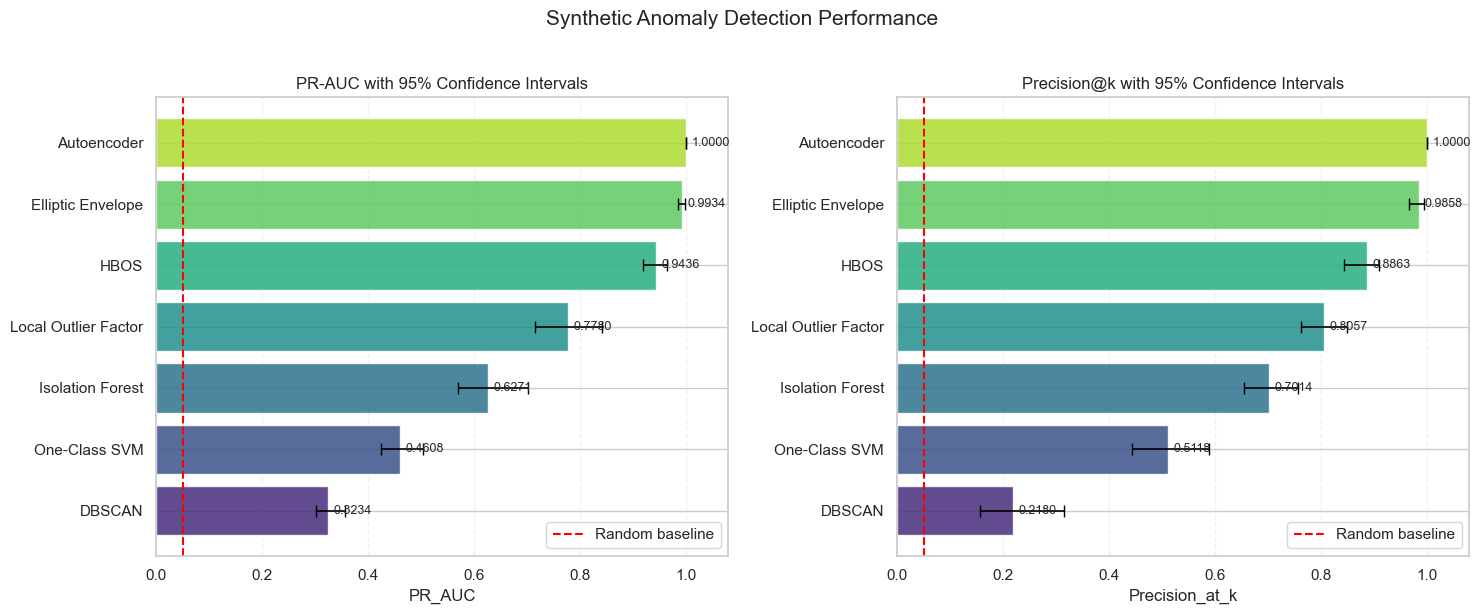

In [23]:
# Visualize final anomaly metrics with 95% confidence intervals.
comparison_plot_df = (
    anomaly_comparison_df
    .sort_values("PR_AUC")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

metric_plot_details = [
    {
        "Metric": "PR_AUC",
        "Lower": "PR_AUC_CI_Lower",
        "Upper": "PR_AUC_CI_Upper",
        "Title": "PR-AUC with 95% Confidence Intervals",
        "Baseline": y_anomaly_benchmark.mean()
    },
    {
        "Metric": "Precision_at_k",
        "Lower": "Precision_at_k_CI_Lower",
        "Upper": "Precision_at_k_CI_Upper",
        "Title": "Precision@k with 95% Confidence Intervals",
        "Baseline": y_anomaly_benchmark.mean()
    }
]

for ax, plot_details in zip(
    axes,
    metric_plot_details
):
    estimates = comparison_plot_df[
        plot_details["Metric"]
    ].to_numpy()

    lower_errors = (
        estimates
        - comparison_plot_df[
            plot_details["Lower"]
        ].to_numpy()
    )

    upper_errors = (
        comparison_plot_df[
            plot_details["Upper"]
        ].to_numpy()
        - estimates
    )

    y_positions = np.arange(
        len(comparison_plot_df)
    )

    bars = ax.barh(
        y_positions,
        estimates,
        color=sns.color_palette(
            "viridis",
            len(comparison_plot_df)
        ),
        alpha=0.85
    )

    ax.errorbar(
        estimates,
        y_positions,
        xerr=np.vstack([
            lower_errors,
            upper_errors
        ]),
        fmt="none",
        ecolor="black",
        capsize=4,
        linewidth=1.2
    )

    ax.axvline(
        plot_details["Baseline"],
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="Random baseline"
    )

    ax.bar_label(
        bars,
        labels=[
            f"{value:.4f}"
            for value in estimates
        ],
        padding=4,
        fontsize=9
    )

    ax.set_yticks(y_positions)
    ax.set_yticklabels(
        comparison_plot_df["Algorithm"]
    )
    ax.set_xlim(0, 1.08)
    ax.set_xlabel(plot_details["Metric"])
    ax.set_title(plot_details["Title"])
    ax.legend(loc="lower right")
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.30
    )

fig.suptitle(
    "Synthetic Anomaly Detection Performance",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

#### 4.5.2 Anomaly Score Distributions

Each detector uses a different numerical score scale. Therefore, scores are converted into percentile ranks from zero to one while preserving their ordering. Values near one represent the most anomalous observations according to that detector.

The distributions compare original weak-normal windows with injected synthetic anomalies. Strong separation indicates that a detector consistently ranks injected anomalies above normal observations.

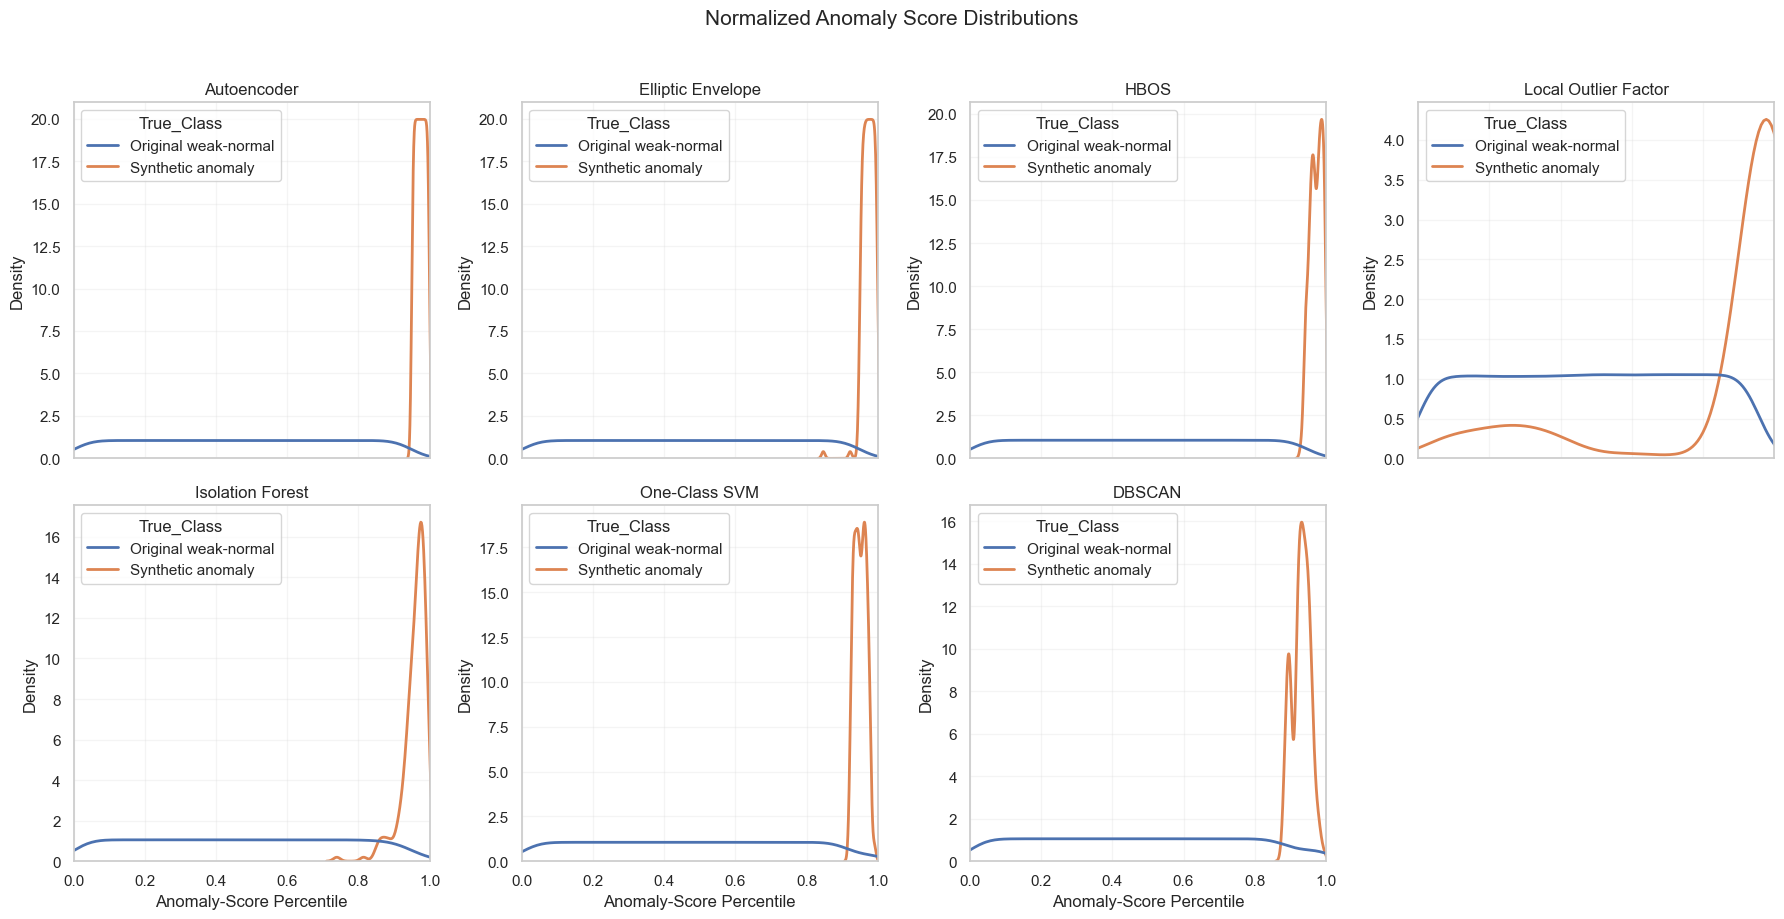

In [24]:
# Compare normalized anomaly-score distributions.
normalized_score_frames = []

for algorithm_name, anomaly_scores in (
    final_anomaly_scores.items()
):
    normalized_scores = (
        pd.Series(anomaly_scores)
        .rank(
            method="average",
            pct=True
        )
        .to_numpy()
    )

    score_frame = pd.DataFrame({
        "Algorithm": algorithm_name,
        "Normalized_Anomaly_Score": (
            normalized_scores
        ),
        "True_Class": np.where(
            y_anomaly_benchmark == 1,
            "Synthetic anomaly",
            "Original weak-normal"
        )
    })

    normalized_score_frames.append(
        score_frame
    )

normalized_anomaly_scores_df = pd.concat(
    normalized_score_frames,
    ignore_index=True
)

algorithm_order = (
    anomaly_comparison_df["Algorithm"]
    .tolist()
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9),
    sharex=True
)

axes = axes.flatten()

for ax, algorithm_name in zip(
    axes,
    algorithm_order
):
    algorithm_scores = (
        normalized_anomaly_scores_df[
            normalized_anomaly_scores_df[
                "Algorithm"
            ] == algorithm_name
        ]
    )

    sns.kdeplot(
        data=algorithm_scores,
        x="Normalized_Anomaly_Score",
        hue="True_Class",
        common_norm=False,
        fill=False,
        linewidth=2,
        bw_adjust=0.8,
        ax=ax
    )

    ax.set_xlim(0, 1)
    ax.set_title(algorithm_name)
    ax.set_xlabel(
        "Anomaly-Score Percentile"
    )
    ax.set_ylabel("Density")
    ax.grid(alpha=0.20)

# Remove the unused eighth subplot.
for unused_ax in axes[
    len(algorithm_order):
]:
    unused_ax.remove()

fig.suptitle(
    "Normalized Anomaly Score Distributions",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

**Observation:** Autoencoder, Elliptic Envelope, and HBOS concentrate synthetic anomalies near the highest anomaly-score percentiles, demonstrating strong separation. Isolation Forest and One-Class SVM also rank most injected anomalies highly but show greater overlap. LOF produces a mixed anomaly distribution, indicating that some injected observations remain locally similar to normal operating modes. DBSCAN shows the weakest separation, consistent with its lower PR-AUC and Precision@k.

### 4.6 Validation Against Reported Failure Intervals

Synthetic anomalies provide controlled ground truth but may be easier to detect than real equipment failures. Therefore, the selected detectors are also evaluated against the weak labels constructed from official maintenance-report intervals.

To avoid data reuse, normal windows previously used for detector training or synthetic tuning are excluded. All 493 reported failure windows are retained, together with a reproducible sample of 7,507 unused normal windows. This produces an 8,000-window validation set that remains imbalanced while keeping DBSCAN computationally manageable.

These results must be interpreted cautiously because maintenance reports provide incomplete weak labels rather than exhaustive anomaly annotations.

In [25]:
# Build an independent weak-failure validation set.
WEAK_VALIDATION_NORMAL_SIZE = 7507

used_normal_timestamps = set(
    pd.concat([
        normal_training_sample["timestamp"],
        normal_evaluation_sample["timestamp"]
    ]).tolist()
)

unused_normal_pool = weak_normal_df[
    ~weak_normal_df["timestamp"].isin(
        used_normal_timestamps
    )
].copy()

if (
    len(unused_normal_pool)
    < WEAK_VALIDATION_NORMAL_SIZE
):
    raise ValueError(
        "Not enough unused normal windows are available."
    )

weak_validation_rng = np.random.default_rng(
    RANDOM_STATE + 200
)

selected_unused_normal_indices = (
    weak_validation_rng.choice(
        len(unused_normal_pool),
        size=WEAK_VALIDATION_NORMAL_SIZE,
        replace=False
    )
)

weak_validation_normal_df = (
    unused_normal_pool
    .iloc[selected_unused_normal_indices]
    .copy()
)

weak_validation_failure_df = (
    metro_model_df[
        metro_model_df[
            "Weak_Failure_Label"
        ] == 1
    ]
    .copy()
)

weak_validation_df = pd.concat([
    weak_validation_normal_df,
    weak_validation_failure_df
], ignore_index=True)

weak_validation_df = (
    weak_validation_df
    .sample(
        frac=1,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

X_weak_validation_raw = (
    weak_validation_df[
        sensor_feature_columns
    ].copy()
)

X_weak_validation = anomaly_scaler.transform(
    X_weak_validation_raw
)

y_weak_validation = (
    weak_validation_df[
        "Weak_Failure_Label"
    ]
    .to_numpy(dtype=int)
)

failure_validation_summary = (
    weak_validation_df[
        weak_validation_df[
            "Weak_Failure_Label"
        ] == 1
    ]
    .groupby("Failure_ID")
    .size()
    .reset_index(name="Windows")
)

training_overlap = (
    weak_validation_normal_df[
        "timestamp"
    ]
    .isin(
        normal_training_sample[
            "timestamp"
        ]
    )
    .any()
)

synthetic_tuning_overlap = (
    weak_validation_normal_df[
        "timestamp"
    ]
    .isin(
        normal_evaluation_sample[
            "timestamp"
        ]
    )
    .any()
)

print(
    "Unused normal windows available:",
    len(unused_normal_pool)
)
print(
    "Selected weak-normal windows:",
    len(weak_validation_normal_df)
)
print(
    "Reported failure windows:",
    len(weak_validation_failure_df)
)
print(
    "Final weak validation shape:",
    X_weak_validation.shape
)
print(
    "Failure prevalence:",
    f"{y_weak_validation.mean() * 100:.2f}%"
)
print(
    "Overlap with detector training normals:",
    training_overlap
)
print(
    "Overlap with synthetic-tuning normals:",
    synthetic_tuning_overlap
)

print("\nFailure intervals retained:")
display(failure_validation_summary)

Unused normal windows available: 14259
Selected weak-normal windows: 7507
Reported failure windows: 493
Final weak validation shape: (8000, 36)
Failure prevalence: 6.16%
Overlap with detector training normals: False
Overlap with synthetic-tuning normals: False

Failure intervals retained:


,Failure_ID,Windows
0,F1,142
1,F2,40
2,F3,284
3,F4,27


**Observation:** The independent weak-label validation set contains 8,000 windows, including all 493 reported failure windows and 7,507 unused normal windows. Both overlap checks are false, confirming that its normal observations were not used for detector training or synthetic parameter tuning. All four maintenance-report intervals remain represented.

#### 4.6.1 Detector Evaluation on Weak Failure Labels

The seven selected detector configurations are applied without further parameter tuning. This provides an independent test of whether performance on designed synthetic perturbations transfers to real maintenance-report intervals.

Because the reported labels are incomplete, a detector may correctly identify unusual unreported behaviour that is counted as a false positive. Therefore, the results measure agreement with maintenance reports rather than perfect anomaly truth.

Precision@k uses \(k=493\), equal to the number of reported failure windows. All metrics use stratified 95% bootstrap confidence intervals.

In [26]:
# Generate weak-label validation scores for all selected detectors.
weak_validation_scores = {}
weak_validation_runtimes = {}


def generate_timed_scores(
    algorithm_name,
    score_function
):
    start_time = time.perf_counter()

    scores = np.asarray(
        score_function(),
        dtype=float
    ).ravel()

    runtime = time.perf_counter() - start_time

    if len(scores) != len(y_weak_validation):
        raise ValueError(
            f"{algorithm_name} returned an incorrect "
            "number of scores."
        )

    if not np.isfinite(scores).all():
        raise ValueError(
            f"{algorithm_name} returned invalid scores."
        )

    weak_validation_scores[
        algorithm_name
    ] = scores

    weak_validation_runtimes[
        algorithm_name
    ] = runtime

    print(
        "Scored:",
        algorithm_name,
        f"({runtime:.4f} seconds)"
    )


generate_timed_scores(
    "Isolation Forest",
    lambda: -best_isolation_model.score_samples(
        X_weak_validation
    )
)

generate_timed_scores(
    "One-Class SVM",
    lambda: -best_ocsvm_model.decision_function(
        X_weak_validation
    )
)

generate_timed_scores(
    "Local Outlier Factor",
    lambda: -best_lof_model.score_samples(
        X_weak_validation
    )
)

generate_timed_scores(
    "Elliptic Envelope",
    lambda: -best_elliptic_model.score_samples(
        X_weak_validation
    )
)

X_weak_autoencoder = np.clip(
    X_weak_validation,
    -AUTOENCODER_CLIP_LIMIT,
    AUTOENCODER_CLIP_LIMIT
)

weak_autoencoder_start = time.perf_counter()

weak_autoencoder_reconstruction = (
    best_autoencoder_model.predict(
        X_weak_autoencoder
    )
)

weak_autoencoder_scores = np.mean(
    (
        X_weak_autoencoder
        - weak_autoencoder_reconstruction
    ) ** 2,
    axis=1
)

weak_validation_scores[
    "Autoencoder"
] = weak_autoencoder_scores

weak_validation_runtimes[
    "Autoencoder"
] = (
    time.perf_counter()
    - weak_autoencoder_start
)

print(
    "Scored: Autoencoder",
    f"({weak_validation_runtimes['Autoencoder']:.4f} seconds)"
)

generate_timed_scores(
    "HBOS",
    lambda: score_hbos(
        best_hbos_model,
        X_weak_validation
    )
)

# DBSCAN is transductive and must be fitted on the validation set.
weak_dbscan_start = time.perf_counter()

weak_neighbor_model = NearestNeighbors(
    n_neighbors=best_dbscan_parameters[
        "min_samples"
    ],
    metric="euclidean",
    n_jobs=-1
)

weak_neighbor_model.fit(
    X_weak_validation
)

weak_neighbor_distances, _ = (
    weak_neighbor_model.kneighbors(
        X_weak_validation
    )
)

weak_kth_neighbor_distance = (
    weak_neighbor_distances[:, -1]
)

weak_dbscan_model = DBSCAN(
    **best_dbscan_parameters,
    metric="euclidean",
    n_jobs=-1
)

weak_dbscan_labels = (
    weak_dbscan_model.fit_predict(
        X_weak_validation
    )
)

weak_dbscan_noise_mask = (
    weak_dbscan_labels == -1
)

weak_dbscan_score_bonus = (
    weak_kth_neighbor_distance.max()
    + 1.0
)

weak_dbscan_scores = (
    weak_kth_neighbor_distance
    + weak_dbscan_noise_mask.astype(float)
    * weak_dbscan_score_bonus
)

weak_validation_scores[
    "DBSCAN"
] = weak_dbscan_scores

weak_validation_runtimes[
    "DBSCAN"
] = (
    time.perf_counter()
    - weak_dbscan_start
)

print(
    "Scored: DBSCAN",
    f"({weak_validation_runtimes['DBSCAN']:.4f} seconds)"
)

# Calculate stratified bootstrap confidence intervals.
WEAK_FAILURE_K = int(
    y_weak_validation.sum()
)

weak_failure_comparison_rows = []
weak_failure_confidence_rows = []

for algorithm_index, (
    algorithm_name,
    anomaly_scores
) in enumerate(
    weak_validation_scores.items()
):
    confidence_df = bootstrap_anomaly_metrics(
        y_weak_validation,
        anomaly_scores,
        k=WEAK_FAILURE_K,
        n_iterations=BOOTSTRAP_ITERATIONS,
        random_state=(
            RANDOM_STATE
            + 300
            + algorithm_index
        )
    )

    metric_lookup = confidence_df.set_index(
        "Metric"
    ).to_dict("index")

    weak_failure_comparison_rows.append({
        "Algorithm": algorithm_name,
        "Precision_at_k": metric_lookup[
            "Precision_at_k"
        ]["Estimate"],
        "Precision_at_k_CI_Lower": metric_lookup[
            "Precision_at_k"
        ]["CI_Lower"],
        "Precision_at_k_CI_Upper": metric_lookup[
            "Precision_at_k"
        ]["CI_Upper"],
        "ROC_AUC": metric_lookup[
            "ROC_AUC"
        ]["Estimate"],
        "ROC_AUC_CI_Lower": metric_lookup[
            "ROC_AUC"
        ]["CI_Lower"],
        "ROC_AUC_CI_Upper": metric_lookup[
            "ROC_AUC"
        ]["CI_Upper"],
        "PR_AUC": metric_lookup[
            "PR_AUC"
        ]["Estimate"],
        "PR_AUC_CI_Lower": metric_lookup[
            "PR_AUC"
        ]["CI_Lower"],
        "PR_AUC_CI_Upper": metric_lookup[
            "PR_AUC"
        ]["CI_Upper"],
        "Scoring_Runtime": (
            weak_validation_runtimes[
                algorithm_name
            ]
        )
    })

    confidence_copy = confidence_df.copy()
    confidence_copy.insert(
        0,
        "Algorithm",
        algorithm_name
    )

    weak_failure_confidence_rows.append(
        confidence_copy
    )

    print(
        "Bootstrapped:",
        algorithm_name
    )

weak_failure_comparison_df = (
    pd.DataFrame(
        weak_failure_comparison_rows
    )
    .sort_values(
        [
            "PR_AUC",
            "Precision_at_k",
            "ROC_AUC"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

weak_failure_confidence_df = pd.concat(
    weak_failure_confidence_rows,
    ignore_index=True
)

# Create a compact, readable display table.
weak_failure_display_df = pd.DataFrame({
    "Algorithm": (
        weak_failure_comparison_df[
            "Algorithm"
        ]
    ),
    "Precision@k [95% CI]": (
        weak_failure_comparison_df.apply(
            lambda row: (
                f"{row['Precision_at_k']:.4f} "
                f"[{row['Precision_at_k_CI_Lower']:.4f}, "
                f"{row['Precision_at_k_CI_Upper']:.4f}]"
            ),
            axis=1
        )
    ),
    "ROC-AUC [95% CI]": (
        weak_failure_comparison_df.apply(
            lambda row: (
                f"{row['ROC_AUC']:.4f} "
                f"[{row['ROC_AUC_CI_Lower']:.4f}, "
                f"{row['ROC_AUC_CI_Upper']:.4f}]"
            ),
            axis=1
        )
    ),
    "PR-AUC [95% CI]": (
        weak_failure_comparison_df.apply(
            lambda row: (
                f"{row['PR_AUC']:.4f} "
                f"[{row['PR_AUC_CI_Lower']:.4f}, "
                f"{row['PR_AUC_CI_Upper']:.4f}]"
            ),
            axis=1
        )
    ),
    "Scoring Runtime": (
        weak_failure_comparison_df[
            "Scoring_Runtime"
        ]
    )
})

print(
    "\nRandom PR-AUC reference:",
    f"{y_weak_validation.mean():.4f}"
)

display(
    weak_failure_display_df.style.format({
        "Scoring Runtime": "{:.4f} seconds"
    })
)

Scored: Isolation Forest (0.1590 seconds)
Scored: One-Class SVM (3.8447 seconds)
Scored: Local Outlier Factor (0.3565 seconds)
Scored: Elliptic Envelope (0.0167 seconds)
Scored: Autoencoder (0.0134 seconds)
Scored: HBOS (0.0217 seconds)
Scored: DBSCAN (5.9256 seconds)
Bootstrapped: Isolation Forest
Bootstrapped: One-Class SVM
Bootstrapped: Local Outlier Factor
Bootstrapped: Elliptic Envelope
Bootstrapped: Autoencoder
Bootstrapped: HBOS
Bootstrapped: DBSCAN

Random PR-AUC reference: 0.0616


,Algorithm,Precision@k [95% CI],ROC-AUC [95% CI],PR-AUC [95% CI],Scoring Runtime
0,HBOS,"0.6775 [0.6471, 0.7160]","0.9821 [0.9785, 0.9854]","0.6342 [0.5989, 0.6762]",0.0217 seconds
1,One-Class SVM,"0.6369 [0.5933, 0.6664]","0.9794 [0.9766, 0.9821]","0.6258 [0.5973, 0.6565]",3.8447 seconds
2,Isolation Forest,"0.5517 [0.5030, 0.5984]","0.9718 [0.9680, 0.9754]","0.4946 [0.4705, 0.5284]",0.1590 seconds
3,Elliptic Envelope,"0.5659 [0.5162, 0.6105]","0.9706 [0.9659, 0.9748]","0.4918 [0.4641, 0.5241]",0.0167 seconds
4,DBSCAN,"0.3753 [0.3296, 0.4158]","0.9529 [0.9474, 0.9582]","0.3798 [0.3603, 0.4027]",5.9256 seconds
5,Autoencoder,"0.0609 [0.0406, 0.0842]","0.6265 [0.6104, 0.6434]","0.0899 [0.0792, 0.1059]",0.0134 seconds
6,Local Outlier Factor,"0.0548 [0.0365, 0.0751]","0.2303 [0.2062, 0.2554]","0.0849 [0.0669, 0.1057]",0.3565 seconds


**Observation:** HBOS achieved the strongest agreement with real maintenance reports, with Precision@k of 0.6775 and PR-AUC of 0.6342, followed closely by One-Class SVM. In contrast, the Autoencoder and LOF performed poorly despite strong synthetic results. This confirms that success on designed perturbations does not guarantee detection of real equipment failures. HBOS is selected as the best overall anomaly detector because it combines the strongest weak-label performance with extremely low scoring runtime.

### 4.7 Semi-Supervised Learning

The semi-supervised experiments use the 8,000-window weak-label validation dataset. A stratified 70:30 split preserves the rare-failure proportion in both training and testing data.

Only 5%, 10%, or 25% of the training labels are revealed. All remaining training labels are replaced with `-1`, while the independent test labels remain hidden from every model until evaluation.

The following methods will be compared:

- supervised learning using only the revealed labels,
- confidence-based self-training,
- Label Propagation,
- Label Spreading,
- co-training using complementary analogue and digital sensor views,
- HBOS as the fully unsupervised lower-bound baseline,
- fully supervised Logistic Regression as the upper-bound baseline.

#### 4.7.1 Semi-Supervised Train-Test Split

The split is stratified because failures represent only 6.16% of the available weak labels. RobustScaler is fitted only on the training partition to avoid leakage.

The analogue view contains pressure, temperature, and motor-current statistics. The digital view contains binary sensor activity ratios. These complementary equipment views will later support co-training, although their conditional independence is only approximate.

In [27]:
# Prepare an independent split for semi-supervised experiments.
SEMI_TEST_SIZE = 0.30
LABELED_FRACTIONS = [0.05, 0.10, 0.25]

semi_train_df, semi_test_df = train_test_split(
    weak_validation_df,
    test_size=SEMI_TEST_SIZE,
    stratify=weak_validation_df[
        "Weak_Failure_Label"
    ],
    random_state=RANDOM_STATE
)

semi_train_df = semi_train_df.reset_index(
    drop=True
)

semi_test_df = semi_test_df.reset_index(
    drop=True
)

X_semi_train_raw = semi_train_df[
    sensor_feature_columns
].copy()

X_semi_test_raw = semi_test_df[
    sensor_feature_columns
].copy()

y_semi_train = semi_train_df[
    "Weak_Failure_Label"
].to_numpy(dtype=int)

y_semi_test = semi_test_df[
    "Weak_Failure_Label"
].to_numpy(dtype=int)

# Fit preprocessing only on the semi-supervised training set.
semi_scaler = RobustScaler()

X_semi_train = semi_scaler.fit_transform(
    X_semi_train_raw
)

X_semi_test = semi_scaler.transform(
    X_semi_test_raw
)

analog_feature_columns = [
    column for column in sensor_feature_columns
    if not column.endswith("_active_ratio")
]

digital_feature_columns = [
    column for column in sensor_feature_columns
    if column.endswith("_active_ratio")
]

analog_feature_indices = [
    sensor_feature_columns.index(column)
    for column in analog_feature_columns
]

digital_feature_indices = [
    sensor_feature_columns.index(column)
    for column in digital_feature_columns
]

split_summary_df = pd.DataFrame([
    {
        "Partition": "Training",
        "Windows": len(y_semi_train),
        "Failures": int(y_semi_train.sum()),
        "Failure_Percentage": (
            y_semi_train.mean() * 100
        )
    },
    {
        "Partition": "Testing",
        "Windows": len(y_semi_test),
        "Failures": int(y_semi_test.sum()),
        "Failure_Percentage": (
            y_semi_test.mean() * 100
        )
    }
])

print("Training shape:", X_semi_train.shape)
print("Testing shape:", X_semi_test.shape)
print("Analogue-view features:", len(analog_feature_indices))
print("Digital-view features:", len(digital_feature_indices))
print(
    "Train-test timestamp overlap:",
    bool(
        set(semi_train_df["timestamp"])
        & set(semi_test_df["timestamp"])
    )
)

display(
    split_summary_df.style.format({
        "Failure_Percentage": "{:.2f}%"
    })
)

Training shape: (5600, 36)
Testing shape: (2400, 36)
Analogue-view features: 28
Digital-view features: 8
Train-test timestamp overlap: False


,Partition,Windows,Failures,Failure_Percentage
0,Training,5600,345,6.16%
1,Testing,2400,148,6.17%


**Observation:** The stratified split produced 5,600 training windows and 2,400 independent test windows, with failure prevalence remaining approximately 6.16% in both partitions. The 36 features divide into 28 analogue statistics and eight digital activity ratios. No timestamp appears in both partitions.

#### 4.7.2 Labeled Subset Construction

Nested labeled subsets are created so that the 5% labels are contained within the 10% subset, which is contained within the 25% subset. Stratification ensures that both normal and failure examples are represented at every fraction.

All unrevealed training labels are assigned `-1`, the convention used by Scikit-learn semi-supervised models.

In [28]:
# Create reproducible, nested, stratified labeled subsets.
label_rng = np.random.default_rng(
    RANDOM_STATE + 400
)

normal_train_indices = np.where(
    y_semi_train == 0
)[0]

failure_train_indices = np.where(
    y_semi_train == 1
)[0]

label_rng.shuffle(normal_train_indices)
label_rng.shuffle(failure_train_indices)

semi_label_sets = {}
labeled_subset_rows = []

for labeled_fraction in LABELED_FRACTIONS:
    normal_label_count = max(
        1,
        int(round(
            len(normal_train_indices)
            * labeled_fraction
        ))
    )

    failure_label_count = max(
        1,
        int(round(
            len(failure_train_indices)
            * labeled_fraction
        ))
    )

    labeled_indices = np.concatenate([
        normal_train_indices[
            :normal_label_count
        ],
        failure_train_indices[
            :failure_label_count
        ]
    ])

    partially_labeled_y = np.full(
        len(y_semi_train),
        -1,
        dtype=int
    )

    partially_labeled_y[labeled_indices] = (
        y_semi_train[labeled_indices]
    )

    semi_label_sets[
        labeled_fraction
    ] = {
        "Labeled_Indices": labeled_indices,
        "Partial_Labels": partially_labeled_y
    }

    labeled_subset_rows.append({
        "Labeled_Fraction": labeled_fraction,
        "Labeled_Windows": len(labeled_indices),
        "Labeled_Normal": normal_label_count,
        "Labeled_Failures": failure_label_count,
        "Unlabeled_Windows": (
            len(y_semi_train)
            - len(labeled_indices)
        )
    })

labeled_subset_df = pd.DataFrame(
    labeled_subset_rows
)

display(
    labeled_subset_df.style.format({
        "Labeled_Fraction": "{:.0%}"
    })
)

print(
    "5% subset contained in 10%:",
    set(
        semi_label_sets[0.05][
            "Labeled_Indices"
        ]
    ).issubset(
        set(
            semi_label_sets[0.10][
                "Labeled_Indices"
            ]
        )
    )
)

print(
    "10% subset contained in 25%:",
    set(
        semi_label_sets[0.10][
            "Labeled_Indices"
        ]
    ).issubset(
        set(
            semi_label_sets[0.25][
                "Labeled_Indices"
            ]
        )
    )
)

,Labeled_Fraction,Labeled_Windows,Labeled_Normal,Labeled_Failures,Unlabeled_Windows
0,5%,280,263,17,5320
1,10%,560,526,34,5040
2,25%,1400,1314,86,4200


5% subset contained in 10%: True
10% subset contained in 25%: True


**Observation:** The 5%, 10%, and 25% subsets contain 17, 34, and 86 labelled failure windows respectively. Both containment checks are true, so changes across fractions reflect the addition of labels rather than unrelated resampling.

**Observation:** The 5%, 10%, and 25% subsets contain 17, 34, and 86 labelled failure windows respectively. Both containment checks are true, so changes across fractions reflect the addition of labels rather than unrelated resampling.

#### 4.7.3 Baselines and Self-Training Sensitivity

A class-balanced Logistic Regression model provides the base classifier.

Three reference levels are established:

- **Unsupervised lower bound:** HBOS with a 5% training-score threshold.
- **Labeled-only baseline:** Logistic Regression trained only on revealed labels.
- **Fully supervised upper bound:** Logistic Regression trained using every training label.

Self-training repeatedly adds unlabeled observations whose predicted probability exceeds a confidence threshold. Thresholds of 0.75, 0.85, and 0.95 are compared. Lower thresholds add more pseudo-labels but increase confirmation-bias risk; higher thresholds are safer but may leave useful observations unlabeled.

Completed: fraction=5%, threshold=0.75
Completed: fraction=5%, threshold=0.85
Completed: fraction=5%, threshold=0.95
Completed: fraction=10%, threshold=0.75
Completed: fraction=10%, threshold=0.85
Completed: fraction=10%, threshold=0.95
Completed: fraction=25%, threshold=0.75
Completed: fraction=25%, threshold=0.85
Completed: fraction=25%, threshold=0.95


,Method,Labeled_Fraction,Threshold,Pseudo_Labels_Added,Accuracy,F1,Runtime
0,Labeled Only,5%,—,0,0.9800,0.8580,—
1,Self-Training,5%,0.75,5319,0.9750,0.8295,3.2026
2,Self-Training,5%,0.85,5320,0.9750,0.8295,2.2896
3,Self-Training,5%,0.95,5319,0.9746,0.8272,7.6170
4,Labeled Only,10%,—,0,0.9788,0.8513,—
5,Self-Training,10%,0.75,5040,0.9762,0.8367,0.5849
6,Self-Training,10%,0.85,5040,0.9758,0.8343,1.0252
7,Self-Training,10%,0.95,5037,0.9758,0.8343,2.3656
8,Labeled Only,25%,—,0,0.9804,0.8605,—
9,Self-Training,25%,0.75,4200,0.9762,0.8367,1.0954



Reference baselines:
Unsupervised HBOS: Accuracy=0.9608, F1=0.6519
Fully supervised: Accuracy=0.9796, F1=0.8563


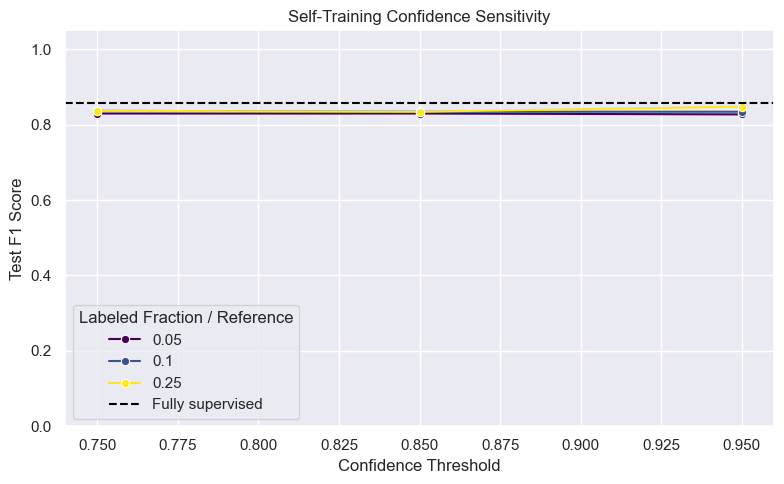

In [29]:
# Evaluate unsupervised, labeled-only, fully supervised, and self-training models.
self_training_thresholds = [0.75, 0.85, 0.95]

semi_supervised_results = []
semi_prediction_store = {}

base_logistic_parameters = {
    "class_weight": "balanced",
    "max_iter": 1500,
    "solver": "liblinear",
    "random_state": RANDOM_STATE
}


def classification_metrics(
    y_true,
    y_pred
):
    return {
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        )
    }


# Fully unsupervised HBOS lower bound.
X_hbos_semi_train = anomaly_scaler.transform(
    X_semi_train_raw
)

X_hbos_semi_test = anomaly_scaler.transform(
    X_semi_test_raw
)

hbos_train_scores = score_hbos(
    best_hbos_model,
    X_hbos_semi_train
)

hbos_test_scores = score_hbos(
    best_hbos_model,
    X_hbos_semi_test
)

hbos_threshold = np.quantile(
    hbos_train_scores,
    0.95
)

hbos_test_predictions = (
    hbos_test_scores >= hbos_threshold
).astype(int)

hbos_metrics = classification_metrics(
    y_semi_test,
    hbos_test_predictions
)

semi_supervised_results.append({
    "Method": "Unsupervised HBOS",
    "Labeled_Fraction": 0.0,
    "Threshold": np.nan,
    "Pseudo_Labels_Added": 0,
    **hbos_metrics
})

semi_prediction_store[
    ("Unsupervised HBOS", 0.0, None)
] = hbos_test_predictions

# Fully supervised upper bound.
fully_supervised_model = LogisticRegression(
    **base_logistic_parameters
)

fully_supervised_model.fit(
    X_semi_train,
    y_semi_train
)

fully_supervised_predictions = (
    fully_supervised_model.predict(
        X_semi_test
    )
)

fully_supervised_metrics = (
    classification_metrics(
        y_semi_test,
        fully_supervised_predictions
    )
)

semi_supervised_results.append({
    "Method": "Fully Supervised",
    "Labeled_Fraction": 1.0,
    "Threshold": np.nan,
    "Pseudo_Labels_Added": 0,
    **fully_supervised_metrics
})

semi_prediction_store[
    ("Fully Supervised", 1.0, None)
] = fully_supervised_predictions

# Labeled-only and self-training experiments.
for labeled_fraction in LABELED_FRACTIONS:
    labeled_indices = semi_label_sets[
        labeled_fraction
    ]["Labeled_Indices"]

    partial_labels = semi_label_sets[
        labeled_fraction
    ]["Partial_Labels"]

    # Supervised model using only revealed labels.
    labeled_only_model = LogisticRegression(
        **base_logistic_parameters
    )

    labeled_only_model.fit(
        X_semi_train[labeled_indices],
        y_semi_train[labeled_indices]
    )

    labeled_only_predictions = (
        labeled_only_model.predict(
            X_semi_test
        )
    )

    labeled_only_metrics = (
        classification_metrics(
            y_semi_test,
            labeled_only_predictions
        )
    )

    semi_supervised_results.append({
        "Method": "Labeled Only",
        "Labeled_Fraction": labeled_fraction,
        "Threshold": np.nan,
        "Pseudo_Labels_Added": 0,
        **labeled_only_metrics
    })

    semi_prediction_store[
        (
            "Labeled Only",
            labeled_fraction,
            None
        )
    ] = labeled_only_predictions

    # Tune the confidence threshold.
    for confidence_threshold in (
        self_training_thresholds
    ):
        self_training_model = (
            SelfTrainingClassifier(
                estimator=LogisticRegression(
                    **base_logistic_parameters
                ),
                threshold=confidence_threshold,
                criterion="threshold",
                max_iter=30,
                verbose=False
            )
        )

        start_time = time.perf_counter()

        self_training_model.fit(
            X_semi_train,
            partial_labels
        )

        self_training_predictions = (
            self_training_model.predict(
                X_semi_test
            )
        )

        runtime = (
            time.perf_counter()
            - start_time
        )

        self_training_metrics = (
            classification_metrics(
                y_semi_test,
                self_training_predictions
            )
        )

        pseudo_labels_added = int(
            np.sum(
                self_training_model.transduction_
                != -1
            )
            - len(labeled_indices)
        )

        semi_supervised_results.append({
            "Method": "Self-Training",
            "Labeled_Fraction": (
                labeled_fraction
            ),
            "Threshold": (
                confidence_threshold
            ),
            "Pseudo_Labels_Added": (
                pseudo_labels_added
            ),
            **self_training_metrics,
            "Runtime": runtime
        })

        semi_prediction_store[
            (
                "Self-Training",
                labeled_fraction,
                confidence_threshold
            )
        ] = self_training_predictions

        print(
            "Completed:",
            f"fraction={labeled_fraction:.0%},",
            f"threshold={confidence_threshold:.2f}"
        )

self_training_results_df = pd.DataFrame(
    semi_supervised_results
)

self_training_display_df = (
    self_training_results_df[
        self_training_results_df[
            "Method"
        ].isin([
            "Labeled Only",
            "Self-Training"
        ])
    ]
    .sort_values([
        "Labeled_Fraction",
        "Method",
        "Threshold"
    ])
    .reset_index(drop=True)
)

display(
    self_training_display_df.style.format({
        "Labeled_Fraction": "{:.0%}",
        "Threshold": "{:.2f}",
        "Accuracy": "{:.4f}",
        "F1": "{:.4f}",
        "Runtime": "{:.4f}"
    }, na_rep="—")
)

print("\nReference baselines:")
print(
    "Unsupervised HBOS:",
    f"Accuracy={hbos_metrics['Accuracy']:.4f},",
    f"F1={hbos_metrics['F1']:.4f}"
)
print(
    "Fully supervised:",
    f"Accuracy={fully_supervised_metrics['Accuracy']:.4f},",
    f"F1={fully_supervised_metrics['F1']:.4f}"
)

# Visualize self-training threshold sensitivity.
self_training_plot_df = (
    self_training_results_df[
        self_training_results_df[
            "Method"
        ] == "Self-Training"
    ]
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=self_training_plot_df,
    x="Threshold",
    y="F1",
    hue="Labeled_Fraction",
    marker="o",
    palette="viridis"
)

plt.axhline(
    fully_supervised_metrics["F1"],
    color="black",
    linestyle="--",
    label="Fully supervised"
)

plt.title("Self-Training Confidence Sensitivity")
plt.xlabel("Confidence Threshold")
plt.ylabel("Test F1 Score")
plt.ylim(0, 1.05)
plt.legend(title="Labeled Fraction / Reference")
plt.tight_layout()
plt.show()

**Observation:** Labeled-only Logistic Regression performed strongly even with 5% labels, achieving F1 = 0.8580. Self-training did not improve performance at any labeled fraction because it pseudo-labelled nearly the entire unlabeled pool. The confidence thresholds produced very similar results, showing that the base classifier was highly confident even when some predictions were incorrect. This is a practical example of confirmation bias: early errors were converted into training labels and reinforced. The unsupervised HBOS baseline remained useful but clearly below the supervised and semi-supervised classifiers.

#### 4.7.4 Label Propagation and Label Spreading

Label Propagation and Label Spreading construct a nearest-neighbour graph over labeled and unlabeled training observations.

Label Propagation allows labeled observations to remain fixed, while Label Spreading permits limited correction through clamping. The number of neighbours controls graph locality: small values preserve local structure, while large values create smoother connections between operating modes.

Neighbour values of 10, 20, and 30 are tested systematically at every labeled fraction. Features are clipped only for numerical stability when constructing the graph.

Completed: Label Propagation fraction=5%, neighbors=10
Completed: Label Spreading fraction=5%, neighbors=10
Completed: Label Propagation fraction=5%, neighbors=20
Completed: Label Spreading fraction=5%, neighbors=20
Completed: Label Propagation fraction=5%, neighbors=30
Completed: Label Spreading fraction=5%, neighbors=30
Completed: Label Propagation fraction=10%, neighbors=10
Completed: Label Spreading fraction=10%, neighbors=10
Completed: Label Propagation fraction=10%, neighbors=20
Completed: Label Spreading fraction=10%, neighbors=20
Completed: Label Propagation fraction=10%, neighbors=30
Completed: Label Spreading fraction=10%, neighbors=30
Completed: Label Propagation fraction=25%, neighbors=10
Completed: Label Spreading fraction=25%, neighbors=10
Completed: Label Propagation fraction=25%, neighbors=20
Completed: Label Spreading fraction=25%, neighbors=20
Completed: Label Propagation fraction=25%, neighbors=30
Completed: Label Spreading fraction=25%, neighbors=30


,Method,Labeled_Fraction,N_Neighbors,Threshold,Pseudo_Labels_Added,Accuracy,F1,Runtime
0,Label Propagation,5%,10,nan,5320,0.9888,0.9148,0.3542
1,Label Spreading,5%,10,nan,5320,0.9904,0.9260,0.1948
2,Label Propagation,5%,20,nan,5320,0.9842,0.8848,0.3263
3,Label Spreading,5%,20,nan,5320,0.9883,0.9119,0.5044
4,Label Propagation,5%,30,nan,5320,0.9804,0.8545,0.7489
5,Label Spreading,5%,30,nan,5320,0.9838,0.8754,1.5413
6,Label Propagation,10%,10,nan,5040,0.9875,0.9013,2.2044
7,Label Spreading,10%,10,nan,5040,0.9896,0.9158,0.4687
8,Label Propagation,10%,20,nan,5040,0.9850,0.8902,0.4843
9,Label Spreading,10%,20,nan,5040,0.9888,0.9132,0.4129


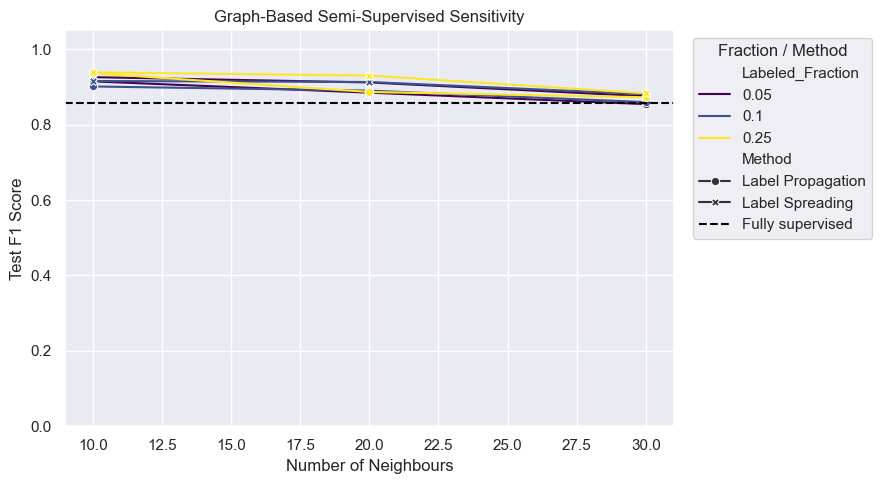

In [30]:
# Tune Label Propagation and Label Spreading.
graph_neighbor_values = [10, 20, 30]

X_graph_train = np.clip(
    X_semi_train,
    -20,
    20
)

X_graph_test = np.clip(
    X_semi_test,
    -20,
    20
)

graph_results = []

for labeled_fraction in LABELED_FRACTIONS:
    partial_labels = semi_label_sets[
        labeled_fraction
    ]["Partial_Labels"]

    for n_neighbors in graph_neighbor_values:
        graph_models = {
            "Label Propagation": LabelPropagation(
                kernel="knn",
                n_neighbors=n_neighbors,
                max_iter=100,
                tol=1e-3,
                n_jobs=-1
            ),
            "Label Spreading": LabelSpreading(
                kernel="knn",
                n_neighbors=n_neighbors,
                alpha=0.20,
                max_iter=100,
                tol=1e-3,
                n_jobs=-1
            )
        }

        for method_name, graph_model in (
            graph_models.items()
        ):
            start_time = time.perf_counter()

            graph_model.fit(
                X_graph_train,
                partial_labels
            )

            graph_predictions = (
                graph_model.predict(
                    X_graph_test
                )
            )

            runtime = (
                time.perf_counter()
                - start_time
            )

            graph_metrics = (
                classification_metrics(
                    y_semi_test,
                    graph_predictions
                )
            )

            result = {
                "Method": method_name,
                "Labeled_Fraction": labeled_fraction,
                "N_Neighbors": n_neighbors,
                "Threshold": np.nan,
                "Pseudo_Labels_Added": (
                    len(y_semi_train)
                    - np.sum(
                        partial_labels != -1
                    )
                ),
                **graph_metrics,
                "Runtime": runtime
            }

            graph_results.append(result)
            semi_supervised_results.append(
                result
            )

            semi_prediction_store[
                (
                    method_name,
                    labeled_fraction,
                    n_neighbors
                )
            ] = graph_predictions

            print(
                "Completed:",
                method_name,
                f"fraction={labeled_fraction:.0%},",
                f"neighbors={n_neighbors}"
            )

graph_results_df = pd.DataFrame(
    graph_results
)

display(
    graph_results_df.style.format({
        "Labeled_Fraction": "{:.0%}",
        "Accuracy": "{:.4f}",
        "F1": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=["F1"],
        color="lightgreen"
    )
)

# Visualize graph-neighbour sensitivity.
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=graph_results_df,
    x="N_Neighbors",
    y="F1",
    hue="Labeled_Fraction",
    style="Method",
    markers=True,
    dashes=False,
    palette="viridis"
)

plt.axhline(
    fully_supervised_metrics["F1"],
    color="black",
    linestyle="--",
    label="Fully supervised"
)

plt.title("Graph-Based Semi-Supervised Sensitivity")
plt.xlabel("Number of Neighbours")
plt.ylabel("Test F1 Score")
plt.ylim(0, 1.05)
plt.legend(
    title="Fraction / Method",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

**Observation:** Graph-based methods substantially outperformed self-training and the fully supervised Logistic Regression baseline. Label Spreading with 25% labels and 10 neighbours achieved the highest F1 Score of 0.9388. Performance generally decreased as the neighbourhood size increased, indicating that local operating patterns are more informative than broadly smoothed connections. Label Spreading usually exceeded Label Propagation because partial clamping reduced the influence of noisy weak labels.

#### 4.7.5 Co-Training with Analogue and Digital Sensor Views

Co-training assumes that two feature views are individually informative and approximately conditionally independent given the class.

MetroPT-3 provides a defensible, though imperfect, split:

- the **analogue view** contains pressure, temperature, and motor-current statistics;
- the **digital view** contains equipment-state activity ratios.

The views describe different aspects of compressor operation, but they interact physically and are therefore not strictly independent. Co-training is implemented as an exploratory method with this limitation explicitly acknowledged.

At each iteration, separate class-balanced Logistic Regression models are trained on both views. Each model proposes its most confident positive and negative pseudo-labels. When both views propose a label for the same window, the prediction with greater confidence is retained. Confidence thresholds of 0.80, 0.90, and 0.95 are compared.

Completed: fraction=5%, threshold=0.80, iterations=15
Completed: fraction=5%, threshold=0.90, iterations=15
Completed: fraction=5%, threshold=0.95, iterations=15
Completed: fraction=10%, threshold=0.80, iterations=15
Completed: fraction=10%, threshold=0.90, iterations=15
Completed: fraction=10%, threshold=0.95, iterations=15
Completed: fraction=25%, threshold=0.80, iterations=15
Completed: fraction=25%, threshold=0.90, iterations=15
Completed: fraction=25%, threshold=0.95, iterations=15


,Method,Labeled_Fraction,Threshold,Pseudo_Labels_Added,Iterations,Accuracy,F1,Runtime
0,Co-Training,5%,0.80,1215,15,0.9708,0.8066,0.3282
1,Co-Training,5%,0.90,1212,15,0.9712,0.8089,0.3831
2,Co-Training,5%,0.95,1211,15,0.9712,0.8089,0.3116
3,Co-Training,10%,0.80,1188,15,0.9725,0.8156,0.3592
4,Co-Training,10%,0.90,1187,15,0.9721,0.8134,0.3859
5,Co-Training,10%,0.95,1187,15,0.9733,0.8202,0.3207
6,Co-Training,25%,0.80,1115,15,0.9729,0.8179,0.5985
7,Co-Training,25%,0.90,1113,15,0.9733,0.8202,0.6740
8,Co-Training,25%,0.95,1100,15,0.9742,0.8249,0.7105


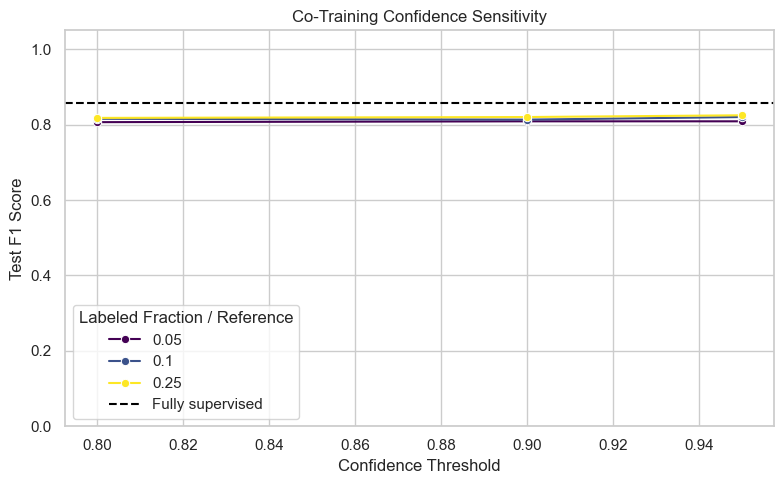

In [31]:
# Implement and tune co-training using analogue and digital feature views.
co_training_thresholds = [0.80, 0.90, 0.95]
CO_TRAINING_MAX_ITERATIONS = 15
CO_TRAINING_ADDITIONS_PER_CLASS = 25


def run_co_training(
    X_analog,
    X_digital,
    partial_labels,
    confidence_threshold,
    max_iterations=CO_TRAINING_MAX_ITERATIONS,
    additions_per_class=CO_TRAINING_ADDITIONS_PER_CLASS
):
    working_labels = np.asarray(
        partial_labels,
        dtype=int
    ).copy()

    iterations_completed = 0

    for iteration in range(max_iterations):
        labeled_mask = working_labels != -1
        unlabeled_indices = np.where(
            working_labels == -1
        )[0]

        if len(unlabeled_indices) == 0:
            break

        analog_model = LogisticRegression(
            **base_logistic_parameters
        )

        digital_model = LogisticRegression(
            **base_logistic_parameters
        )

        analog_model.fit(
            X_analog[labeled_mask],
            working_labels[labeled_mask]
        )

        digital_model.fit(
            X_digital[labeled_mask],
            working_labels[labeled_mask]
        )

        analog_probabilities = (
            analog_model.predict_proba(
                X_analog[unlabeled_indices]
            )
        )

        digital_probabilities = (
            digital_model.predict_proba(
                X_digital[unlabeled_indices]
            )
        )

        proposals = {}

        for view_probabilities in [
            analog_probabilities,
            digital_probabilities
        ]:
            for class_label in [0, 1]:
                class_probabilities = (
                    view_probabilities[
                        :,
                        class_label
                    ]
                )

                confident_positions = np.where(
                    class_probabilities
                    >= confidence_threshold
                )[0]

                if len(confident_positions) == 0:
                    continue

                ordered_positions = (
                    confident_positions[
                        np.argsort(
                            class_probabilities[
                                confident_positions
                            ]
                        )[::-1]
                    ]
                )

                selected_positions = (
                    ordered_positions[
                        :additions_per_class
                    ]
                )

                for position in selected_positions:
                    original_index = (
                        unlabeled_indices[position]
                    )

                    confidence = float(
                        class_probabilities[position]
                    )

                    previous_proposal = (
                        proposals.get(
                            original_index
                        )
                    )

                    if (
                        previous_proposal is None
                        or confidence
                        > previous_proposal[1]
                    ):
                        proposals[original_index] = (
                            class_label,
                            confidence
                        )

        if not proposals:
            break

        for observation_index, (
            proposed_label,
            _
        ) in proposals.items():
            working_labels[
                observation_index
            ] = proposed_label

        iterations_completed = iteration + 1

    final_labeled_mask = working_labels != -1

    final_analog_model = LogisticRegression(
        **base_logistic_parameters
    )

    final_digital_model = LogisticRegression(
        **base_logistic_parameters
    )

    final_analog_model.fit(
        X_analog[final_labeled_mask],
        working_labels[final_labeled_mask]
    )

    final_digital_model.fit(
        X_digital[final_labeled_mask],
        working_labels[final_labeled_mask]
    )

    return {
        "Analog_Model": final_analog_model,
        "Digital_Model": final_digital_model,
        "Transduction": working_labels,
        "Iterations": iterations_completed
    }


X_analog_train = X_semi_train[
    :,
    analog_feature_indices
]

X_analog_test = X_semi_test[
    :,
    analog_feature_indices
]

X_digital_train = X_semi_train[
    :,
    digital_feature_indices
]

X_digital_test = X_semi_test[
    :,
    digital_feature_indices
]

co_training_results = []

for labeled_fraction in LABELED_FRACTIONS:
    partial_labels = semi_label_sets[
        labeled_fraction
    ]["Partial_Labels"]

    initial_labeled_count = int(
        np.sum(partial_labels != -1)
    )

    for confidence_threshold in (
        co_training_thresholds
    ):
        start_time = time.perf_counter()

        co_training_output = run_co_training(
            X_analog_train,
            X_digital_train,
            partial_labels,
            confidence_threshold
        )

        analog_test_probabilities = (
            co_training_output[
                "Analog_Model"
            ].predict_proba(
                X_analog_test
            )[:, 1]
        )

        digital_test_probabilities = (
            co_training_output[
                "Digital_Model"
            ].predict_proba(
                X_digital_test
            )[:, 1]
        )

        combined_probabilities = (
            analog_test_probabilities
            + digital_test_probabilities
        ) / 2

        co_training_predictions = (
            combined_probabilities >= 0.50
        ).astype(int)

        runtime = time.perf_counter() - start_time

        co_training_metrics = (
            classification_metrics(
                y_semi_test,
                co_training_predictions
            )
        )

        pseudo_labels_added = int(
            np.sum(
                co_training_output[
                    "Transduction"
                ] != -1
            )
            - initial_labeled_count
        )

        result = {
            "Method": "Co-Training",
            "Labeled_Fraction": labeled_fraction,
            "Threshold": confidence_threshold,
            "Pseudo_Labels_Added": (
                pseudo_labels_added
            ),
            "Iterations": (
                co_training_output[
                    "Iterations"
                ]
            ),
            **co_training_metrics,
            "Runtime": runtime
        }

        co_training_results.append(result)
        semi_supervised_results.append(result)

        semi_prediction_store[
            (
                "Co-Training",
                labeled_fraction,
                confidence_threshold
            )
        ] = co_training_predictions

        print(
            "Completed:",
            f"fraction={labeled_fraction:.0%},",
            f"threshold={confidence_threshold:.2f},",
            f"iterations={result['Iterations']}"
        )

co_training_results_df = pd.DataFrame(
    co_training_results
)

display(
    co_training_results_df.style.format({
        "Labeled_Fraction": "{:.0%}",
        "Threshold": "{:.2f}",
        "Accuracy": "{:.4f}",
        "F1": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=["F1"],
        color="lightgreen"
    )
)

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=co_training_results_df,
    x="Threshold",
    y="F1",
    hue="Labeled_Fraction",
    marker="o",
    palette="viridis"
)

plt.axhline(
    fully_supervised_metrics["F1"],
    color="black",
    linestyle="--",
    label="Fully supervised"
)

plt.title("Co-Training Confidence Sensitivity")
plt.xlabel("Confidence Threshold")
plt.ylabel("Test F1 Score")
plt.ylim(0, 1.05)
plt.legend(title="Labeled Fraction / Reference")
plt.tight_layout()
plt.show()

**Observation:** Co-training performed best with 25% labels and a confidence threshold of 0.95, achieving F1 = 0.8249. Higher confidence and more labeled data produced small improvements, but all configurations remained below the fully supervised baseline. The analogue and digital views describe complementary sensor groups, but their physical dependence violates strict co-training independence. Consequently, errors from one view can be reinforced rather than corrected by the other.

#### 4.7.6 Final Semi-Supervised Comparison

For each method and labeled fraction, the configuration with the highest F1 Score is selected. Accuracy and F1 are reported with stratified 95% bootstrap confidence intervals using 500 resamples.

The fully supervised Logistic Regression model is a reference upper-bound model for the same linear classifier family. It is not a theoretical upper bound for every possible algorithm; nonlinear graph-based methods may outperform it by exploiting local manifold structure.

In [32]:
# Select the best tested configuration for every method and labeled fraction.
all_semi_results_df = pd.DataFrame(
    semi_supervised_results
)

selected_semi_results_df = (
    all_semi_results_df
    .sort_values(
        [
            "Method",
            "Labeled_Fraction",
            "F1",
            "Accuracy"
        ],
        ascending=[True, True, False, False]
    )
    .groupby(
        ["Method", "Labeled_Fraction"],
        as_index=False
    )
    .head(1)
    .reset_index(drop=True)
)


def get_selected_prediction(row):
    method_name = row["Method"]
    labeled_fraction = float(
        row["Labeled_Fraction"]
    )

    if method_name in [
        "Label Propagation",
        "Label Spreading"
    ]:
        setting = int(row["N_Neighbors"])

    elif method_name in [
        "Self-Training",
        "Co-Training"
    ]:
        setting = float(row["Threshold"])

    else:
        setting = None

    prediction_key = (
        method_name,
        labeled_fraction,
        setting
    )

    return np.asarray(
        semi_prediction_store[prediction_key],
        dtype=int
    )


def bootstrap_classification_metrics(
    y_true,
    y_pred,
    n_iterations=500,
    confidence_level=0.95,
    random_state=RANDOM_STATE
):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    normal_indices = np.where(
        y_true == 0
    )[0]

    failure_indices = np.where(
        y_true == 1
    )[0]

    bootstrap_rng = np.random.default_rng(
        random_state
    )

    accuracy_values = []
    f1_values = []

    for _ in range(n_iterations):
        sampled_normal = bootstrap_rng.choice(
            normal_indices,
            size=len(normal_indices),
            replace=True
        )

        sampled_failure = bootstrap_rng.choice(
            failure_indices,
            size=len(failure_indices),
            replace=True
        )

        sample_indices = np.concatenate([
            sampled_normal,
            sampled_failure
        ])

        bootstrap_rng.shuffle(sample_indices)

        accuracy_values.append(
            accuracy_score(
                y_true[sample_indices],
                y_pred[sample_indices]
            )
        )

        f1_values.append(
            f1_score(
                y_true[sample_indices],
                y_pred[sample_indices],
                zero_division=0
            )
        )

    alpha = (
        1 - confidence_level
    ) / 2

    return {
        "Accuracy_CI_Lower": np.quantile(
            accuracy_values,
            alpha
        ),
        "Accuracy_CI_Upper": np.quantile(
            accuracy_values,
            1 - alpha
        ),
        "F1_CI_Lower": np.quantile(
            f1_values,
            alpha
        ),
        "F1_CI_Upper": np.quantile(
            f1_values,
            1 - alpha
        )
    }


final_semi_rows = []

for row_index, (_, row) in enumerate(
    selected_semi_results_df.iterrows()
):
    predictions = get_selected_prediction(row)

    confidence_intervals = (
        bootstrap_classification_metrics(
            y_semi_test,
            predictions,
            n_iterations=500,
            random_state=(
                RANDOM_STATE
                + 500
                + row_index
            )
        )
    )

    if row["Method"] in [
        "Label Propagation",
        "Label Spreading"
    ]:
        selected_parameter = (
            f"neighbors={int(row['N_Neighbors'])}"
        )

    elif row["Method"] in [
        "Self-Training",
        "Co-Training"
    ]:
        selected_parameter = (
            f"threshold={row['Threshold']:.2f}"
        )

    else:
        selected_parameter = "—"

    final_semi_rows.append({
        "Method": row["Method"],
        "Labeled_Fraction": row[
            "Labeled_Fraction"
        ],
        "Selected_Parameter": selected_parameter,
        "Accuracy": row["Accuracy"],
        **{
            "Accuracy_CI_Lower":
                confidence_intervals[
                    "Accuracy_CI_Lower"
                ],
            "Accuracy_CI_Upper":
                confidence_intervals[
                    "Accuracy_CI_Upper"
                ]
        },
        "F1": row["F1"],
        **{
            "F1_CI_Lower":
                confidence_intervals[
                    "F1_CI_Lower"
                ],
            "F1_CI_Upper":
                confidence_intervals[
                    "F1_CI_Upper"
                ]
        }
    })

    print(
        "Bootstrapped:",
        row["Method"],
        f"({row['Labeled_Fraction']:.0%})"
    )

final_semi_comparison_df = (
    pd.DataFrame(final_semi_rows)
    .sort_values(
        [
            "Labeled_Fraction",
            "F1"
        ],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

# Create a compact table for notebook display.
final_semi_display_df = pd.DataFrame({
    "Method": final_semi_comparison_df[
        "Method"
    ],
    "Labeled Fraction": (
        final_semi_comparison_df[
            "Labeled_Fraction"
        ]
    ),
    "Selected Parameter": (
        final_semi_comparison_df[
            "Selected_Parameter"
        ]
    ),
    "Accuracy [95% CI]": (
        final_semi_comparison_df.apply(
            lambda row: (
                f"{row['Accuracy']:.4f} "
                f"[{row['Accuracy_CI_Lower']:.4f}, "
                f"{row['Accuracy_CI_Upper']:.4f}]"
            ),
            axis=1
        )
    ),
    "F1 [95% CI]": (
        final_semi_comparison_df.apply(
            lambda row: (
                f"{row['F1']:.4f} "
                f"[{row['F1_CI_Lower']:.4f}, "
                f"{row['F1_CI_Upper']:.4f}]"
            ),
            axis=1
        )
    )
})

display(
    final_semi_display_df.style.format({
        "Labeled Fraction": "{:.0%}"
    })
)

best_semi_result = (
    final_semi_comparison_df
    .sort_values(
        ["F1", "Accuracy"],
        ascending=False
    )
    .iloc[0]
)

print("\nBest semi-supervised result:")
print(
    best_semi_result["Method"],
    "| Fraction:",
    f"{best_semi_result['Labeled_Fraction']:.0%}",
    "| Parameter:",
    best_semi_result["Selected_Parameter"],
    "| F1:",
    f"{best_semi_result['F1']:.4f}"
)

Bootstrapped: Co-Training (5%)
Bootstrapped: Co-Training (10%)
Bootstrapped: Co-Training (25%)
Bootstrapped: Fully Supervised (100%)
Bootstrapped: Label Propagation (5%)
Bootstrapped: Label Propagation (10%)
Bootstrapped: Label Propagation (25%)
Bootstrapped: Label Spreading (5%)
Bootstrapped: Label Spreading (10%)
Bootstrapped: Label Spreading (25%)
Bootstrapped: Labeled Only (5%)
Bootstrapped: Labeled Only (10%)
Bootstrapped: Labeled Only (25%)
Bootstrapped: Self-Training (5%)
Bootstrapped: Self-Training (10%)
Bootstrapped: Self-Training (25%)
Bootstrapped: Unsupervised HBOS (0%)


,Method,Labeled Fraction,Selected Parameter,Accuracy [95% CI],F1 [95% CI]
0,Unsupervised HBOS,0%,—,"0.9608 [0.9539, 0.9675]","0.6519 [0.5879, 0.7134]"
1,Label Spreading,5%,neighbors=10,"0.9904 [0.9867, 0.9942]","0.9260 [0.8981, 0.9537]"
2,Label Propagation,5%,neighbors=10,"0.9888 [0.9842, 0.9925]","0.9148 [0.8851, 0.9425]"
3,Labeled Only,5%,—,"0.9800 [0.9742, 0.9852]","0.8580 [0.8227, 0.8916]"
4,Self-Training,5%,threshold=0.75,"0.9750 [0.9688, 0.9808]","0.8295 [0.7951, 0.8655]"
5,Co-Training,5%,threshold=0.90,"0.9712 [0.9644, 0.9767]","0.8089 [0.7731, 0.8396]"
6,Label Spreading,10%,neighbors=10,"0.9896 [0.9856, 0.9933]","0.9158 [0.8852, 0.9469]"
7,Label Propagation,10%,neighbors=10,"0.9875 [0.9827, 0.9917]","0.9013 [0.8655, 0.9342]"
8,Labeled Only,10%,—,"0.9788 [0.9725, 0.9842]","0.8513 [0.8156, 0.8852]"
9,Self-Training,10%,threshold=0.75,"0.9762 [0.9696, 0.9821]","0.8367 [0.7989, 0.8728]"



Best semi-supervised result:
Label Spreading | Fraction: 25% | Parameter: neighbors=10 | F1: 0.9388


**Observation:** Label Spreading with 25% labeled data and 10 neighbours produced the best semi-supervised result, with Accuracy = 0.9925 and F1 = 0.9388. Its confidence interval also remained above the fully supervised Logistic Regression reference. Graph-based methods performed strongly even with 5% labels, indicating that nearby MetroPT-3 operating windows often share failure status. Self-training and co-training remained below the labeled-only baseline because unreliable pseudo-labels reinforced early classification errors.

#### 4.7.7 Semi-Supervised Learning Curves

The learning curves compare the best configuration of each method at 5%, 10%, and 25% labeled data. The fully supervised and unsupervised results are displayed as reference lines.

These curves show how additional labels affect both overall Accuracy and failure-class F1 Score. F1 is particularly important because Accuracy can appear high even when rare failures are missed.

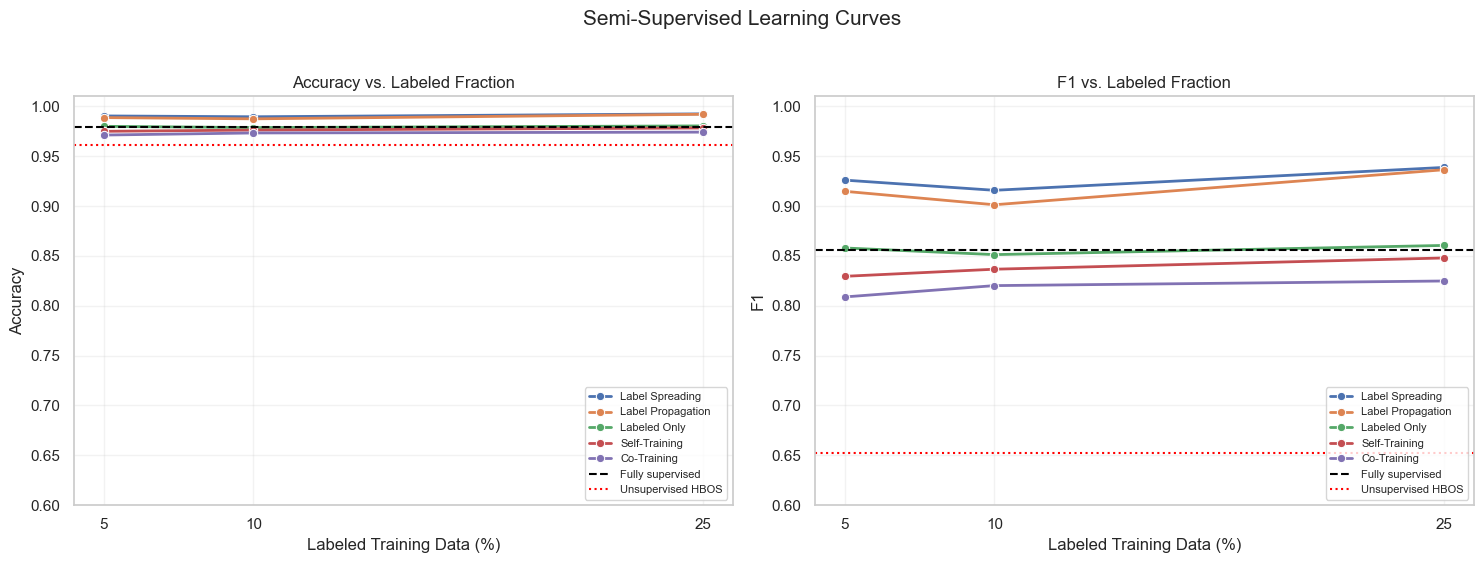

In [33]:
# Visualize Accuracy and F1 against the labeled fraction.
learning_curve_methods = [
    "Labeled Only",
    "Self-Training",
    "Label Propagation",
    "Label Spreading",
    "Co-Training"
]

learning_curve_df = (
    final_semi_comparison_df[
        final_semi_comparison_df[
            "Method"
        ].isin(learning_curve_methods)
    ]
    .copy()
)

learning_curve_df["Labeled_Percentage"] = (
    learning_curve_df["Labeled_Fraction"]
    * 100
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5)
)

for ax, metric_name in zip(
    axes,
    ["Accuracy", "F1"]
):
    sns.lineplot(
        data=learning_curve_df,
        x="Labeled_Percentage",
        y=metric_name,
        hue="Method",
        marker="o",
        linewidth=2,
        ax=ax
    )

    ax.axhline(
        fully_supervised_metrics[
            metric_name
        ],
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="Fully supervised"
    )

    ax.axhline(
        hbos_metrics[metric_name],
        color="red",
        linestyle=":",
        linewidth=1.5,
        label="Unsupervised HBOS"
    )

    ax.set_xticks([5, 10, 25])
    ax.set_xlabel("Labeled Training Data (%)")
    ax.set_ylabel(metric_name)
    ax.set_ylim(0.60, 1.01)
    ax.set_title(
        f"{metric_name} vs. Labeled Fraction"
    )
    ax.grid(alpha=0.25)

    handles, labels = (
        ax.get_legend_handles_labels()
    )

    unique_legend = dict(
        zip(labels, handles)
    )

    ax.legend(
        unique_legend.values(),
        unique_legend.keys(),
        fontsize=8,
        loc="lower right"
    )

fig.suptitle(
    "Semi-Supervised Learning Curves",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

**Observation:** Accuracy remained high for every method because normal windows dominate the dataset, while F1 revealed substantial differences in failure detection. Label Spreading and Label Propagation consistently performed best. Their performance improved at 25% labeled data, whereas self-training and co-training remained below the labeled-only baseline.

### 4.8 Final Pipeline Selection and Saving Results

HBOS is selected as the final anomaly detector because it achieved the highest PR-AUC on real weak failure labels while requiring very little scoring time.

Label Spreading with 25% labeled data and 10 neighbours is selected as the final semi-supervised model because it achieved the highest failure-class F1 Score.

The comparison tables, confidence intervals, final predictions, and full-dataset HBOS anomaly scores are saved for model interpretation in Notebook 5.

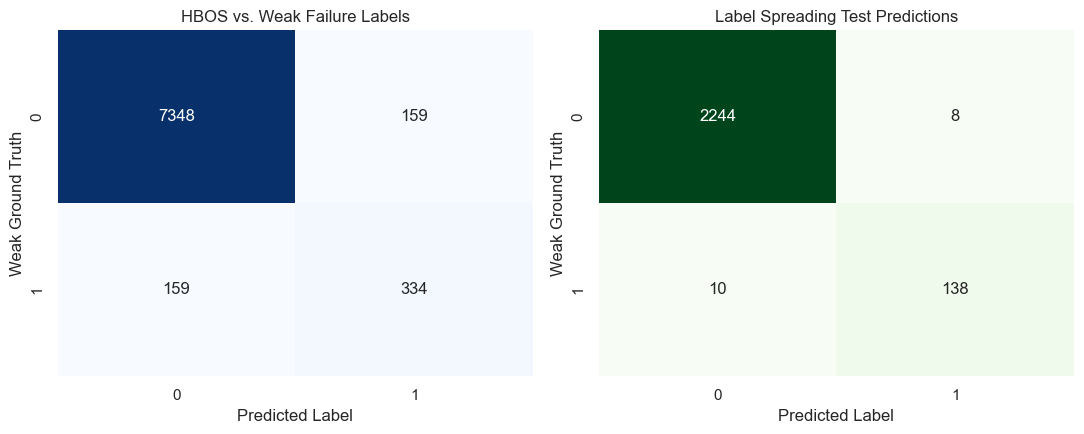

Selected anomaly detector: HBOS
Selected semi-supervised model: Label Spreading | 25% labels | 10 neighbours
Full HBOS anomaly flags: 1549 out of 24752

Saved Notebook 4 files:
- synthetic_anomaly_comparison.csv
- weak_failure_anomaly_comparison.csv
- semi_supervised_comparison.csv
- metropt3_hbos_full_predictions.csv
- metropt3_hbos_validation_predictions.csv
- metropt3_label_spreading_test_predictions.csv


In [34]:
# Create final predictions for the selected weak-label anomaly detector.
best_anomaly_name = "HBOS"
best_anomaly_scores = weak_validation_scores[
    best_anomaly_name
]

best_anomaly_k = int(
    y_weak_validation.sum()
)

best_anomaly_indices = np.argpartition(
    best_anomaly_scores,
    -best_anomaly_k
)[-best_anomaly_k:]

best_anomaly_predictions = np.zeros(
    len(best_anomaly_scores),
    dtype=int
)

best_anomaly_predictions[
    best_anomaly_indices
] = 1

# Retrieve the selected semi-supervised predictions.
best_semi_predictions = semi_prediction_store[
    ("Label Spreading", 0.25, 10)
]

# Display confusion matrices for both final pipelines.
fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5)
)

anomaly_confusion = confusion_matrix(
    y_weak_validation,
    best_anomaly_predictions
)

semi_confusion = confusion_matrix(
    y_semi_test,
    best_semi_predictions
)

sns.heatmap(
    anomaly_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0]
)

axes[0].set_title("HBOS vs. Weak Failure Labels")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("Weak Ground Truth")

sns.heatmap(
    semi_confusion,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    ax=axes[1]
)

axes[1].set_title("Label Spreading Test Predictions")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("Weak Ground Truth")

plt.tight_layout()
plt.show()

# Score every complete MetroPT-3 window with the selected HBOS model.
X_full_metro_scaled = anomaly_scaler.transform(
    metro_model_df[
        sensor_feature_columns
    ]
)

full_hbos_scores = score_hbos(
    best_hbos_model,
    X_full_metro_scaled
)

# Use the 95th percentile of normal training scores as the operational threshold.
hbos_operational_threshold = np.quantile(
    score_hbos(
        best_hbos_model,
        X_anomaly_train
    ),
    0.95
)

full_hbos_predictions = (
    full_hbos_scores
    >= hbos_operational_threshold
).astype(int)

# Prepare reusable output tables.
full_hbos_output_df = pd.DataFrame({
    "timestamp": metro_model_df["timestamp"],
    "Weak_Failure_Label": metro_model_df[
        "Weak_Failure_Label"
    ],
    "Failure_ID": metro_model_df[
        "Failure_ID"
    ],
    "HBOS_Anomaly_Score": full_hbos_scores,
    "HBOS_Anomaly_Flag": full_hbos_predictions
})

weak_validation_output_df = pd.DataFrame({
    "timestamp": weak_validation_df["timestamp"],
    "Weak_Failure_Label": y_weak_validation,
    "HBOS_Anomaly_Score": best_anomaly_scores,
    "HBOS_TopK_Prediction": (
        best_anomaly_predictions
    )
})

semi_test_output_df = pd.DataFrame({
    "timestamp": semi_test_df["timestamp"],
    "Weak_Failure_Label": y_semi_test,
    "Label_Spreading_Prediction": (
        best_semi_predictions
    )
})

# Save Notebook 4 outputs.
results_directory.mkdir(
    parents=True,
    exist_ok=True
)

anomaly_comparison_df.to_csv(
    results_directory
    / "synthetic_anomaly_comparison.csv",
    index=False
)

weak_failure_comparison_df.to_csv(
    results_directory
    / "weak_failure_anomaly_comparison.csv",
    index=False
)

final_semi_comparison_df.to_csv(
    results_directory
    / "semi_supervised_comparison.csv",
    index=False
)

full_hbos_output_df.to_csv(
    results_directory
    / "metropt3_hbos_full_predictions.csv",
    index=False
)

weak_validation_output_df.to_csv(
    results_directory
    / "metropt3_hbos_validation_predictions.csv",
    index=False
)

semi_test_output_df.to_csv(
    results_directory
    / "metropt3_label_spreading_test_predictions.csv",
    index=False
)

print("Selected anomaly detector: HBOS")
print(
    "Selected semi-supervised model:",
    "Label Spreading | 25% labels | 10 neighbours"
)
print(
    "Full HBOS anomaly flags:",
    int(full_hbos_predictions.sum()),
    "out of",
    len(full_hbos_predictions)
)
print("\nSaved Notebook 4 files:")

for filename in [
    "synthetic_anomaly_comparison.csv",
    "weak_failure_anomaly_comparison.csv",
    "semi_supervised_comparison.csv",
    "metropt3_hbos_full_predictions.csv",
    "metropt3_hbos_validation_predictions.csv",
    "metropt3_label_spreading_test_predictions.csv"
]:
    print("-", filename)

**Observation:** HBOS correctly detected 334 of 493 reported failure windows, with 159 false positives and 159 missed failures under the top-k decision rule. Label Spreading produced substantially stronger classification, correctly identifying 138 of 148 test failures while generating only eight false alarms. The operational HBOS threshold flagged 1,549 of 24,752 complete windows for later interpretation.

### Conclusion

This notebook completed the required anomaly detection and semi-supervised learning pipeline on the MetroPT-3 industrial air-compressor dataset.

Seven anomaly detection methods were systematically tuned and evaluated against two controlled synthetic injection mechanisms. The Autoencoder achieved perfect synthetic-benchmark performance, while Elliptic Envelope and HBOS also performed strongly. However, validation against independent maintenance-report intervals showed that synthetic performance did not always transfer to real equipment behaviour.

HBOS was selected as the final anomaly detector because it achieved the highest weak-label PR-AUC of 0.6342 and Precision@k of 0.6775 while requiring only 0.0217 seconds for scoring. Its strong efficiency and real-failure performance make it suitable for further interpretation. ROC-AUC was consistently higher than PR-AUC, demonstrating why PR-AUC is more informative when failures are rare.

Semi-supervised experiments used nested labeled fractions of 5%, 10%, and 25%. Self-training pseudo-labelled almost the entire unlabeled pool and failed to outperform the labeled-only baseline, illustrating confirmation bias. Co-training also remained weaker because the analogue and digital sensor views are physically related and do not fully satisfy conditional independence.

Graph-based methods performed best. Label Spreading with 25% labeled data and 10 neighbours achieved Accuracy of 0.9925 and F1 of 0.9388. It correctly identified 138 of 148 test failures with only eight false-positive alerts. Label Spreading also performed strongly with only 5% labeled data, showing that the local sensor manifold contains useful information for propagating weak failure labels.

The results remain limited by incomplete maintenance reports, possible unreported anomalies, artificially designed benchmark anomalies, and the concentration of failure examples in a small number of intervals. Consequently, all reported metrics measure agreement with available weak labels rather than complete knowledge of equipment condition.

The final HBOS scores, anomaly flags, Label Spreading predictions, comparison tables, and bootstrap confidence intervals were saved for model interpretation and comparative analysis in Notebook 5.